# <b>ADM 3080 — Analítica con Python — Universidad San Francisco de Quito</b>
<h2><b>Proyecto de Prueba Técnica</b></h2>
<i>Viernes, 24 de abril de 2026</i>
<hr>
<ul>
    <li><b>Integrantes del Grupo</b>: Santiago Arellano [00328370]</li>
    <li><b>NRC del Curso</b>: 2041</li>
    <li><b>Profesor</b>: Juan Felipe Nájera Puente</li>
</ul>
<hr>

## Sección I: Introducción al Proyecto

En esta sección se presentará una visión general del proyecto, analizando la base de datos y definiendo métricas de calidad para los datos, orientadose en la definición de límites por métricas faltantes e.g. límites porcentuales tolerables de anclajes con inicio pero sin registro de terminación, etc. Además se analizará el tipo de dato esperado por cada una de las clases y se establecerán criterios para la limpieza de datos, incluyendo la identificación y manejo de valores atípicos, datos faltantes y errores de formato. Se discutirá la importancia de la calidad de los datos en el contexto del análisis y cómo una limpieza adecuada puede mejorar la precisión y confiabilidad de los resultados obtenidos a partir de los datos.

### Contexto del Dataset y el Problema

El dataset representa datos registrados de una aplicación de Wellness desarrollada por Yana, una empresa mexicana orientada a ofrecer un servicio de acompañamiento a individuos para desarrollar su mejor versión. Los datos recopilados atienden a una sola sección de la aplicación, el registro de *anclajes* correspondientes a actividades de bienestar como **volver al presente (Present)** o **distraer mi mente (Mind)** registradas junto con la fecha y hora de inicio y terminación de la actividad. Además, el dataset contiene información correspondiente al proceso, sea iniciar o terminar una actividad de anclaje y datos anonimizados de los usuarios.

Debido a las leyes de protección de datos generales, la empresa ha optado por la anonimización de los datos, usando un cifrado, muy probablemente SHA256 o alguna variante interna de tipo *one way* para reducir la posibilidad de identificación de los usuarios. El tipo de cifrado además, dificulta la agregación de datos mediante IDS, por lo que no podemos asumir la posibilidad de identificar el proceso de cerrado y apertura de una actividad en base a un ID específico, dado que los IDs de inicio y terminación de una actividad no necesariamente coincidirán, lo que complica la identificación de actividades completas. Esto se traduce en la necesidad de eliminar esta columna del análisis, tanto el ID registrado bajo la columna de &lt;anonymous&gt; junto con el id registrado en la columna de IDs no son necesarios para un análisis de datos de agregación, no datos por usuario.

En este contexto, la gerencia ha definido diferentes preguntas de análisis que se usarán para orientar diferentes niveles de marketing, UX design y otras áreas afines a esta aplicación y *customer journey* planteado para mejorar la experiencia de usuario.

<hr>

### Preguntas de Análisis expandidas
1. ¿Cuál es la frecuencia de uso de cada técnica de anclaje?
    <blockquote>En este caso, la frecuencia de uso se traduce directamente a la cantidad de sesiones por tecnica de anclaje iniciada, lo que se puede medir de dos formas distintas, agregadas sobre el dataset (visión general para gerencia), o una visión análitica, con un gráfico de área organizado por día de la semana, més o año. En este caso, el dataset proporcionado agrega información diaria, lo que nos permitiría visualizar la tendencia de uso por día de la semana junto con el mes para determinar la relación entre día de la semana y actividad.
    <br><br>
    Asimismo, el nivel de agregación por día se puede usar para medir mediante agregaciones al 100% la distribución porcentual de las actividades registradas, lo que permitiría identificar la técnica de anclaje más utilizada por los usuarios, lo que a su vez podría ser útil para orientar campañas de marketing o mejorar la experiencia de usuario en torno a esta técnica.
    <br><br>
    En este contexto, entonces, hay tres diferentes formas de evaluar esta frecuencia, la primera es una agregación totalizada, que permite ver durante todo el periodo de análisis los resultados de las actividades, la segunda es una visualización por día mediante líneas, mostrando la suma totalizada de actividades, y la tercera es una distribución porcentual por día, más visual, más facil de entender para personas no técnicas y con poco tiempo para revisar visualizaciones complejas.
    </blockquote>
2. ¿Qué porcentaje de usuarios finaliza cada tipo de ejercicio?
    <blockquote>
    Para esta pregunta, la información importante es la visión desglosada por día y por tipo de actividad. Cuando hablamos de porcentaje de usuarios finalizados, debemos de tomar en cuenta que para cada tipo de actividad existe la posibilidad que un usuario entre, y nunca salga, o entre y salga, o entre y salga de la aplicación y no termine la actividad, por lo que tenemos que comparar la cantidad de registros de inicio y fin de actividades. De nuevo esta pregunta tiene dos niveles diferentes de agregación. El nivel general, del dataset completo, corresponde a la totalización de eventos cerrados y abiertos y la diferencia porcentual para evaluar si existen deficiencias entre la apertura de algunos tipos de actividades comparados con otros, lo que podría indicar problemas de experiencia de usuario o falta de interés en ciertas actividades.
     <br><br>
     El segundo nivel de análisis corresponde a la evaluación por día, lo que permitiría identificar tendencias específicas en ciertos días de la semana o meses, lo que podría ser útil para orientar campañas de marketing o mejorar la experiencia de usuario en torno a estas técnicas. Para la primera visualización, una visualización en torno a barras apiladas al 100% sería ideal para mostrar la distribución porcentual a nivel de actividades, mientras que para la visión diaria, una visualización de líneas mostrando la tendencia de finalización por día sería ideal para mostrar la evolución de esta métrica a lo largo del tiempo.
     <br><br>
     Una tercera visualización efectiva corresponde a usar un diagrama de tipo sankey donde todos los usuarios registrados que han iniciado se distribuyan a la terminación de sus eventos, este tipo de gráfico es fuerte para una visualización de transición en el flujo y es intuitivo dado que mostraría la diferencia entre el ingreso de usuarios al iniciar la actividad y la baja cantidad de usuarios posibles al terminar la misma.
    </blockquote>
3. ¿Qué técnicas suelen utilizarse juntas en una misma sesión o en momentos cercanos?
    <blockquote>
    Para esta pregunta, es importate definir primero que significa durante una misma sesión, o durante momentos cercanos. Dado que no tenemos una información accionable del usuario, dado que no tenemos IDs agrupables y no tenemos forma de regresar de la encriptación de los PII de los usuarios, no podemos analizar en general mediante usuarios. Por otro lado, si bien tenemos inforamción de fecha y hora, no existe un registro que indique que estos eventos fueron parte de una misma sesión, por lo que para esta pregunta vamos a asumir que **una sesión dentro de la aplicación puede dura una hora o más** que sería nuestro indicador de que si dentro de una misma sesión (en el rango de 1 hora) se inician más de una actividad entonces tenemos una sesión y podemos evaluar la cantidad de eventos que se realizan juntos.
    <br><br>
    Para evaluar eventos que se realizen en eventos cercanos, podemos usar una noción de que un evento cercano corresponde a eventos **que se inician dentro de 30 minutos** entre sí, lo que nos permitiría centrar este concepto de momentos cercanos y analizar que eventos se inician seguidos en un periodo de 30 minutos de análisis luego de una actividad iniciada.
    </blockquote>

<hr>

### Guía base de la estructura del dataset

Los datos están distribuidos en un solo archivo *CSV*, importando desde *GitHub Raw links* para mayor comodidad a la hora de ejecutar este cuaderno de Python en otros sistemas en donde el acceso a archivos csv, la forma de manejar archivos del sistema operativo o la ubicación del archivo podrían causar problemas de ejecución innecesarios. En base de este archivo *CSV* y la guía del dataset se ha definido el siguiente listado de los campos y su respectiva descripción.

 <div style="display: flex; align-items:center; align-self:center; justify-content:center">
  <table style="margin: auto; border-collapse: collapse; width: 80%; text-align: center; border: 1px solid black;">
      <thead>
          <tr style="background-color: #f2f2f2;">
              <th style="border: 1px solid black; padding: 8px;">Campo</th>
              <th style="border: 1px solid black; padding: 8px;">Tipo de Dato Esperado</th>
              <th style="border: 1px solid black; padding: 8px;">Descripción</th>
          </tr>
      </thead>
      <tbody>
          <tr>
              <td style="border: 1px solid black; padding: 8px;">id</td>
              <td style="border: 1px solid black; padding: 8px;">Entero</td>
              <td style="border: 1px solid black; padding: 8px;">ID de identificación única del registro</td>
          </tr>
          <tr>
              <td style="border: 1px solid black; padding: 8px;">event</td>
              <td style="border: 1px solid black; padding: 8px;">Texto</td>
              <td style="border: 1px solid black; padding: 8px;">Tipo de evento registrado</td>
          </tr>
          <tr>
              <td style="border: 1px solid black; padding: 8px;">techniqueID</td>
              <td style="border: 1px solid black; padding: 8px;">Texto</td>
              <td style="border: 1px solid black; padding: 8px;">ID de la técnica utilizada</td>
          </tr>
          <tr>
              <td style="border: 1px solid black; padding: 8px;">date</td>
              <td style="border: 1px solid black; padding: 8px;">Fecha</td>
              <td style="border: 1px solid black; padding: 8px;">Fecha en que ocurrió el evento</td>
          </tr>
      </tbody>
  </table>
  </div>

En el contexto del trabajo de análisis a desarrollar, notamos que la parte más importante a considerar es el desarrollo de métricas de calidad para las columnas de evento, tipo de técnica y fecha, dado que en base a estas se construye todo el análisis base de las preguntas definidas para la prueba.

<hr>

### Consideraciones de Limpieza por Columna

No se considera necesario la modificación de la columna de ID (será eliminada al no ser útil para la identificación de patrones de usuarios o de actividades), y tampoco para techniqueID dado que los datos registrados se encuentran definidos en base a las mismas clases, lo que garantiza que no existan datos incorrectos en esta clase.

#### <code>event</code>

<i><small>Esta columna, que define el tipo de evento disparado desde la UI de la aplicación para el módulo de actividades de anclaje puede tomar dos valores específicos: <code>{"Grounding Started","Grounding Ended"}</code> que corresponden al inicio y fin de una actividad de anclaje que registra los datos de esta en las columnas adicionales de date y techniqueID.</small></i>

El principal problema de event es que no sabemos si los eventos se disparan solo por **terminar una sesión** o si también se disparan **automáticamente cuando una sesión no se termina por mucho tiempo**, o si por ejemplo se disparan cuando el **usuario sale de la aplicación durante una sesión**. Esta ambigüedad de la razón de terminación es un problema considerable dado que:
1. Si la sesión marcó **Grounding Ended** debido a un timeout en una actividad, no se la puede considerar como cerrada y por ejemplo esto sería una clase faltante en los datos, que sería una clase de tipo *Grounding Timeout* que de estar presente nos permitiría identificar una tercera clase de terminación útil para un análisis adicional, lo que puede ser una sugerencia de mejora para el equipo de sistemas con respecto a los datos recopilados por la aplicación.
2. Si la sesión marcó **Grounding Ended** debido a una salida de la aplicación por el usuario entonces es posible que tengamos multiples registros de *Grounding Ended* seguidos si por ejemplo el usuario tiene que responder a llamadas, mensajes, o atender a otros requerimientos de sus vidas por fuera de la aplicación. Esta puede ser una razón por la que existen varios registros seguidos, que varían por minutos en algunos casos, de terminaciones.
3. Si la sesión marcó **Grounding Ended** debido a una terminación normal, entonces no existe un problema de calidad de datos, dado que el evento se disparó correctamente y se puede usar para el análisis.

Dado que una visión general de los datos basados en el archivo .csv propuesto, muestra que los primeros datos registran un evento de **Grounding Start** y luego cinco diferentes eventos de cierre a la misma hora, con una duración de 1 minuto luego de una apertura de proceso, esto nos muestra que puede existir un problema de calidad de datos con respecto al segundo escenario de **Grouding Ended**.

<b><small>En este caso, aunque no podemos inferir que tipo de datos se registran en los registros duplicados, podemos tomar dos rutas diferentes de análisis, eliminando entradas duplicadas en base del tipo de evento, acción y hora, lo que nos podría ayudar a reducir el problema de duplicados, otra alternativa es notar su existencia pero mantenerlos en el dataset para argumentar sobre ellos luego</small></b>

#### <code>date</code>

<hr style="height:1px;border:none;color:#333;background-color:#333;">

<i><small>Esta columna registra la fecha y hora exacta de inicio y fin de la actividad. La fecha se registra en un formato de mm/dd/yyyy formato que es similar al usado en EEUU, lo que nos permite una conversión directa en terminos de fecha para su análisis posterior. Además el dataset registra la fecha en formato hh:mm con formato de 24h en lugar de solo 12, lo que nos indica un formato de datos mucho más estandarizado enfocado en la utilidad de los datos bajo sistemas estandarizados para formatos en-US y hora basado en 24.</small></i>

En este caso, en base a la columna de fecha y hora podemos realizar los siguientes pasos de análisis:

1. Primero, **dividir la columna de date en dos, date y time** para poder realizar análisis de datos diferenciados sin tener que realizar una modificación *inline* a la columna de datos durante el análisis.
2. Segundo, **derivar día de la semana, nombre del día, mes, año y nombre del mes** en base de la columna de *date* para extraer datos para agregaciones de tipo timeseries en base a fechas en primera instancia y para agrupaciones por día de la semana o nombre del mes.
3. Tercero, **en base a nuestros periodos base de longitud de actividad y eventos cercanos** podemos derivar columnas de tipo *session* y *eventos cercanos* para poder realizar análisis de tipo sesión y eventos cercanos, lo que nos permitiría responder a la pregunta número 3 de nuestro análisis.

<b><small>En este caso, no existe una remediación de datos necesaria pero si una derivación de columnas adicionales para un análisis profundo de datos.</small></b>

### Librerías Requeridas para el Análisis

Para el presente proyecto, se ha optado por trabajar mediante un entorno *managed* de Python a través de *Python Venv(s)* permitiendo el aislamiento de las librerías requeridas para el trabajo. En este contexto, los comandos a ejecutar a continuación se encargan de la instalación de varias librerías para el trabajo, lo que requiere que Python se encuentre instalado y definido dentro del **PATH** o en su caso, en la carpeta de configuración */bin* o */sbin*.
<br><br>
Para la realización del trabajo, se ha considerado necesario la inclusión de diversas librerías. El siguiente listado detalla la razón de la inclusión de la librería en el desarrollo del proyecto:

<div style="display: flex; align-items:center; align-self:center; justify-content:center">
<table style="margin: auto; border-collapse: collapse; width: 80%; text-align: justify; border: 1px solid black;">
    <thead>
        <tr style="background-color: #f2f2f2;">
            <th style="border: 1px solid black; padding: 8px;">Librería</th>
            <th style="border: 1px solid black; padding: 8px;">Uso</th>
        </tr>
    </thead>
    <tbody>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Numpy</td>
            <td style="border: 1px solid black; padding: 8px;">Librería de análisis numérico con fuertes características para operaciones algebráicas, matriciales y con un backend implementado en C++ por lo que permitirá la realización de operaciones numéricas rápidamente.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Pandas</td>
            <td style="border: 1px solid black; padding: 8px;">Librería base para el análisis del archivo CSV, su manipulación en forma de carga, datos, y agregaciones que permitirán dar respuesta a las preguntas de investigación definidas.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Matplotlib</td>
            <td style="border: 1px solid black; padding: 8px;">Base de las visualizaciones en el caso de ser necesarias para el desarrollo del proyecto o la exploración visual de los datos.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Seaborn</td>
            <td style="border: 1px solid black; padding: 8px;">Apoyo a Matplotlib en el caso de requerir visualizaciones más avanzadas.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Squarify</td>
            <td style="border: 1px solid black; padding: 8px;">Apoyo a Matplotlib para la realización de Treemaps en Python.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">SciPy</td>
            <td style="border: 1px solid black; padding: 8px;">Para pruebas de hipótesis estadísticas (t-test, Mann-Whitney, etc.).</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">WordCloud</td>
            <td style="border: 1px solid black; padding: 8px;">Para mapas de palabras como visualizacion de peso por clase.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">Plotly</td>
            <td style="border: 1px solid black; padding: 8px;">Para gráficos adicionales.</td>
        </tr>
        <tr>
            <td style="border: 1px solid black; padding: 8px;">MissingNo</td>
            <td style="border: 1px solid black; padding: 8px;">Para gráficos adicionales especializados en al visualización de valores nulos.</td>
        </tr>
    </tbody>
</table>
</div>
<br><br>
En este contexto, las librerías seran importadas  usando un álias al nombre original para facilidad de uso durante el desarrollo del proyecto.

In [43]:
#? 1. Importacion de librerias para el proyecto
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from seaborn.palettes import _ColorPalette
from datetime import timedelta
from itertools import combinations
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from typing import Any, Dict, List, Tuple
import plotly.express as px

### Importe del Dataset

In [44]:
#? 1. Importamos el dataset directamente desde su archivo para evitar problemas con la red

dataset_location = '../../../src/res/data/ProyectoPruebaTecnicaADM3080_YanaRaw.csv'

data_as_is = pd.read_csv(dataset_location, sep=',')
data_to_explore = data_as_is.copy(deep=True)
data_cleaned = data_as_is.copy(deep=True)


## Sección II: Análisis de Calidad de los Datos Iniciales

En esta sección se realizará un análisis inicial de los datos, revisando distribución de valores mediante agrupaciones, conteos, visualizaciones de peso mediante wordcloud, y conteo de nulos. Para valores de tipo fecha se realizará un análisis en base a una corrección inline (previa a la definición del dataset procesado) para analizar la distribución de fechas y de horas visualmente.


### Exploracion Inicial de los Datos

In [45]:
#? 1. Exploracion de la forma del dataset, describe e info
print(f"El dataset tiene {data_as_is.shape[0]} filas")
print(f"El dataset tiene {data_as_is.shape[1]} columnas")


El dataset tiene 540023 filas
El dataset tiene 5 columnas


In [46]:
#? 2. Exploracion de las variables del dataset
data_as_is.describe(include='all')


,Unnamed: 0,id,event,techniqueID,date
count,5.400230e+05,5.400230e+05,540023,540023,540023
unique,NaN,NaN,2,5,80416
top,NaN,NaN,Grounding Ended,present,2/9/2022 15:10
freq,NaN,NaN,272487,168500,131
mean,6.629799e+05,6.656979e+05,NaN,NaN,NaN
std,3.817372e+05,3.817372e+05,NaN,NaN,NaN
min,1.000000e+00,2.719000e+03,NaN,NaN,NaN
25%,3.330420e+05,3.357600e+05,NaN,NaN,NaN
50%,6.628060e+05,6.655240e+05,NaN,NaN,NaN
75%,9.935295e+05,9.962475e+05,NaN,NaN,NaN


In [47]:
#? 3. Exploracion del dataset mediante info
data_as_is.info()


<class 'pandas.DataFrame'>
RangeIndex: 540023 entries, 0 to 540022
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   Unnamed: 0   540023 non-null  int64
 1   id           540023 non-null  int64
 2   event        540023 non-null  str  
 3   techniqueID  540023 non-null  str  
 4   date         540023 non-null  str  
dtypes: int64(2), str(3)
memory usage: 39.9 MB


En este contexto, notamos que el dataset no contiene valores nulos, lo que nos muestra que en realidad el dataset estaría limpio, aunque sabemos que existen errores lógicos de registro de datos, hasta donde se puede observar en las columnas presentes no existen errores de registro.

Además, el tipo de dato de las columnas nos muestra que el error registrado corresponde a `date` en donde el tipo de dato se registra como una cadena de texto en lugar de un tipo datetime, por lo que la corrección en este case se centrará en esta columna.

Por otro lado, notamos que el tipo de evento corresponde a una columna de tipo string, que podríamos convertir en columnas numéricas booleanas en base a un proceso de One Hot Encoding en esa columna.

Por último, notamos que tenemos una columna `Unnamed: 0` e `id` que podemos eliminar dado que no representan información útil para el análisis.

In [48]:
#? 4. Exploracion de los datos mediante una visualizacion de los diez datos iniciales y finales del dataset

print(f"{'Valores Iniciales':=^120}")
display(data_as_is.head(10))
print()
print(f"{'Valores Finales':=^120}")
display(data_as_is.tail(10))


===================================================Valores Iniciales====================================================


,Unnamed: 0,id,event,techniqueID,date
0,1,2719,Grounding Started,present,1/12/2022 14:06
1,2,2720,Grounding Ended,present,1/12/2022 14:06
2,3,2721,Grounding Ended,present,1/12/2022 14:07
3,4,2722,Grounding Ended,present,1/12/2022 14:07
4,5,2723,Grounding Ended,present,1/12/2022 14:07
5,6,2724,Grounding Ended,present,1/12/2022 14:07
6,10,2728,Grounding Started,categories,1/12/2022 14:07
7,11,2729,Grounding Ended,categories,1/12/2022 14:08
8,15,2733,Grounding Started,body,1/12/2022 14:08
9,17,2735,Grounding Ended,body,1/12/2022 14:09



====================================================Valores Finales=====================================================


,Unnamed: 0,id,event,techniqueID,date
540013,1323276,1325994,Grounding Ended,present,3/16/2022 16:44
540014,1323278,1325996,Grounding Ended,categories,3/16/2022 16:44
540015,1323282,1326000,Grounding Started,categories,3/16/2022 16:44
540016,1323283,1326001,Grounding Started,categories,3/16/2022 16:44
540017,1323284,1326002,Grounding Ended,present,3/16/2022 16:44
540018,1323286,1326004,Grounding Ended,present,3/16/2022 16:45
540019,1323287,1326005,Grounding Ended,present,3/16/2022 16:45
540020,1323292,1326010,Grounding Ended,categories,3/16/2022 16:45
540021,1323299,1326017,Grounding Started,body,3/16/2022 16:46
540022,1323300,1326018,Grounding Started,present,3/16/2022 16:46


### Drill Down por Atributo: exploración de las características internas del dataset por columna de datos

<hr>

#### Exploración de event

Para esta variable, se realizará un análisis de la cantidad de registros de cada tipo de variable, para realizar una visualización general y luego agregada por cada tipo de evento. Dado que no tenemos una variable numérica, no se realizará ningún análisis de tipo de distribución.

In [49]:
#? 1. Exploracion del conteo de valores nulos, negativos si existen y no nulos positivos
print(f"{'Conteo General de valores: Nulos, No Nulos y Negativos, No Nulos y Positivos':=^120}")
result = pd.DataFrame(data={
    'Conteo de Nulos': data_as_is['event'].isna().sum(),
    'Conteo No Nulo ': data_as_is['event'].count()
},index=['Conteo']).T

result.loc['Total',:] = result.sum(axis=0)

result


======================Conteo General de valores: Nulos, No Nulos y Negativos, No Nulos y Positivos======================


,Conteo
Conteo de Nulos,0.0
Conteo No Nulo,540023.0
Total,540023.0


In [50]:
#? 2. Exploracion de la distribucion entre evento terminado y evento iniciado
print(f"{'Conteo de eventos por tipo':=^120}")
result = data_as_is['event'].value_counts().T.to_frame()


for entry in result.index:
    count = result.loc[entry, "count"]
    percentage = (count / data_as_is.shape[0]) * 100
    result.loc[entry, "Percentage"] = percentage
result


===============================================Conteo de eventos por tipo===============================================


,count,Percentage
event,,
Grounding Ended,272487,50.458406
Grounding Started,267536,49.541594


In [51]:
#? 2.1 Exploracion de la diferencia de valores generales del dataset en el tipo de eventos
print(f"Diferencia Iniciados  - Terminados: {result.loc['Grounding Started','count'] - result.loc['Grounding Ended','count']}")


Diferencia Iniciados  - Terminados: -4951


Como podemos notar, en la visión de los datos generales, tenemos 4951 entradas más de tipo **Grounding Ended** que las entradas que tenemos de tipo **Grounding Stared** lo que nos indica que en general el dataset está desbalanceado en un 1% de los datos hacia el conteo de eventos de terminación comparado con los eventos de inicio de anclajes.

Si bien la visión general es alentadora para la distribución paritaria de las clases, el siguiente análisis, orientado a los diferentes tipos de anclajes y el conteo de los valores de ended o started puede resultar aún más revelador.

In [52]:
#? 3. Exploracion de la distribucion de eventos de inicio y finalizacion por cada tipo de anclaje
result = data_as_is.groupby(by='techniqueID')['event'].value_counts(sort=True)


conteo_y_proporcion_de_eventos_por_tecnica = pd.DataFrame(
    {
        "conteo": result,
        "proporcion": result.groupby(level=0).transform(lambda x: x /x.sum()).apply(lambda v: f"{round(v*100,2)} %")
    },
    index = result.index
)

conteo_y_proporcion_de_eventos_por_tecnica


conteo proporcion
techniqueID event                               
body        Grounding Started   48989    59.54 %
            Grounding Ended     33293    40.46 %
breathing   Grounding Started   39173    55.81 %
            Grounding Ended     31019    44.19 %
categories  Grounding Started   86433    67.56 %
            Grounding Ended     41497    32.44 %
mind        Grounding Started   55539    60.95 %
            Grounding Ended     35580    39.05 %
present     Grounding Ended    131098     77.8 %
            Grounding Started   37402     22.2 %

En este caso, notamos que para las clases de **body y breathing** el dataset muestra información espearada, es decir, que los eventos de *°Grounding Started* tengan un mayor porcentaje comparado con *Grounding Ended* lo que indica que los clientes tienden a terminar este tipo de actividades.

Por otro lado, notamos casos como el de **categories o mind** en donde el conteo de actividades de inicio es casi el doble del conteo de datos para los eventos de terminación de las actividades, lo que nos muestra que estos tipos de anclaje *generalmente se inician (lo que es bueno para la empresa), pero no se terminan*.

Por último, el caso más extraordinario corresponde al caso de **present** en donde la proporción se invierte, hay muchos más registros de terminación (es decir de tipo *Grounding Ended*) comparado con los registros de tipo *Grounding Started* lo que nos muestra un problema claro en el registro de datos. Si tomamos en cuenta nuestro análisis del tipo posible de registros de *Grounding Started*, si consideramos que esta columna registra un evento de tipo de finalización y que la razón entre un registro de inicio con el de finalización es de casi 4 a 1, tenemos un problema de que **aparentemente la mayoría de las personas terminan actividades present, sin siquiera haber pasado por un flujo que inicie la actividad o registre su inicio**

Esto puede apuntar a dos problemas técnicos de la aplicación y recopilación de datos.
1. Dada la alta tasa de valores de terminación comparada con los valores iniciales, la aplicación tiene un problema real en el registro de la actividad de tipo **present**, en específico, el registro de inicio de actividad no está registrando el punto de inicio de la actividad, y esto genera que muchos usuarios que pueden estar usando la aplicación, vean su actividad como terminada pero el sistema nunca la vió como siquiera iniciada.
2. Por otro lado, si el sistema no tiene un problema al registrar actividades, entonces el problema corresponde al proceso de *signaling* de terminación de la actividad. Es posible que el sistema registre apropiadamente 37K eventos de inicio, los eventos reales de los usuarios, pero al final registre este dato tres o cuatro veces por problemas en el diseño del backend de la aplicación, donde se crean multiples registros en la base de datos de un mismo usuario. En este caso, el problema de calidad de datos es claro, y se recomienda una revisión del proceso de registro de datos para esta actividad, dado que el análisis de los datos muestra un problema claro en la calidad de los datos registrados para esta actividad, lo que puede afectar la precisión y confiabilidad de los resultados obtenidos a partir de estos datos.

De cualquier forma, notamos que existen dos problemas paralelos en el dataset, y que afectan de manera distinta a cada uno de los tipos de anclaje.

1. El primer problema corresponde a un problema de calidad de datos para la actividad de tipo **present** en donde el sistema no registra apropiadamente los eventos de inicio, lo que genera un desbalance claro entre los eventos de inicio y terminación, lo que puede afectar la precisión y confiabilidad de los resultados obtenidos a partir de estos datos.
2. El segundo problema corresponde a un problema de calidad de datos para las actividades de tipo **body, breathing, categories y mind** en donde el sistema registra muchas más actividades de inicio que actividades de finalización, lo que puede indicar un problema de registro de la aplicación, como se mencionó en casos de que no tolere salidas de la aplicación, no tenga timeouts establecidos, o no tolere cancelaciones con otro tipo. En este caso, dado que el porcentaje de los datos se acumula en los eventos de inicio de actividad, el problema claramente recae en un sistema de ingesta de datos que no prevee situaciones como salidas de la aplicación en donde un usuario puede no regresar a la aplicación *por horas o días* y si el sistema solo deja de mantener un estado vivo de esa actividad, entonces claramente tendríamos actividades huérfanas.

Desde nuestro punto como analístas no podemos realizar una modificación de los datos, ni una imputación porque no podemos asumir que hubo un timeout o una salida de la aplicación en base de los datos registrados. Además, el ID incremental del usuario no nos permite realizar uniones para determinar si son eventos reales o duplicados, dado que hasta donde ve el sistema, los eventos son unicos y coherentes.

Una posible solución es la eliminación de los datos duplicados teniendo en cuenta un subset de columnas, es decir, evento, el ID de la actividad y la hora, para reducir la cantidad de eventos duplicados a una copia única de cada registro e igualar los datos. Si bien este mecanismo es útil, dado que afecta  la columna de eventos es posible que elimine registros reales de inicio de actividades por ser al mismo momento o la misma actividad (lo que podría apuntar a que la aplicación registra eventos registrados rápidamente como un doble clic sobre el botón de iniciar actividad dos veces), y lo que podría eliminar registros de tipo cancelación duplicados, o eventos reales que cancelan actividades de varios usuarios.

En general como el dataset contiene datos de diferentes usuarios, no se considera apropiado la eliminación o imputación de datos, dado que representan falencias del sistema y no datos poco problables o poco útiles para nuestro análisis.

=================================================Head (5) stacked data==================================================
event        Grounding Ended  Grounding Started
techniqueID                                    
body                   33293              48989
breathing              31019              39173
categories             41497              86433
mind                   35580              55539
present               131098              37402
=================================================Head (5) stacked data==================================================
event        Grounding Started  Grounding Ended
techniqueID                                    
body                     48989            33293
breathing                39173            31019
categories               86433            41497
mind                     55539            35580
present                  37402           131098
=================================================Head (5) stacked data================

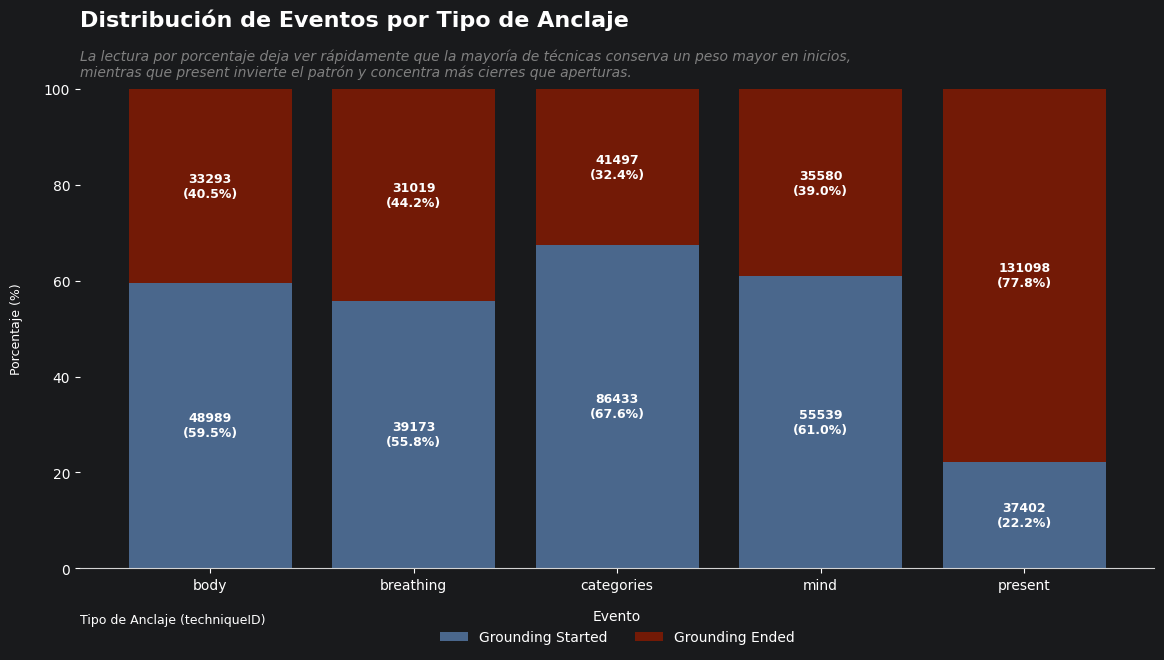

In [53]:
#? 4. Exploracion visual de los conteos de porcentajes por cada tipo de anclaje

def generate_blue_palette(n: int) -> _ColorPalette:
    """
    Funcion encargada de generar una paleta de colores replicable en base de la paleta built-in de Blues de Seaborn
    y usando el parametro n para determinar cuantos colores generar y retornar para la visualizacion
    :param n: entero representativo de la cantidad de colores necesarios
    :return: listado de colores
    """
    return sns.color_palette("Blues", n)



#? 4.1 Generamos datos para el stack bar chart en base del conteo de valores de cada evento agrupado por categorias
stacked_data = data_as_is.groupby('techniqueID')['event'].value_counts().unstack(fill_value=0)
print(f"{'Head (5) stacked data':=^120}")
print(stacked_data.head(5))
stacked_data = stacked_data.reindex(columns=['Grounding Started', 'Grounding Ended'])
print(f"{'Head (5) stacked data':=^120}")
print(stacked_data.head(5))
#? 4.2 Calculamos el procentaje a mostrar en base de la suma por columnas y una division con el valor por filas
stacked_pct = stacked_data.div(stacked_data.sum(axis=1), axis=0) * 100
print(f"{'Head (5) stacked data':=^120}")
print(stacked_pct.head(5))

#? 4.2 Visualizacion de distribucion de eventos por tipo de anclaje
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#4A678C', '#731A06']


#? 4.3 Definimos un loop para el graficado mediante Matplotlib, en este caso creamos bottom para definir la base de la columna en zero y la altura el porcentaje
bottom = np.zeros(len(stacked_pct))
# 4.3.1 Iteramos sobre los porcentajes por columna
for i, col in enumerate(stacked_pct.columns):
    # 4.3.2 Creamos la bara
    bars = ax.bar(stacked_pct.index, stacked_pct[col], bottom=bottom, color=colors[i], label=col)
    # 4.3.3 Iteramos sobre las barras creadas para anadir el label
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            count = stacked_data.iloc[j][col]
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + height / 2,
                f'{count}\n({height:.1f}%)',
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
    # 4.3.4 Al bottom que inicio en zero le anadimos el porcentaje para la siguiente parte de la columna
    bottom += stacked_pct[col].values

#? 4.4 Titulo y subtitulo storytelling
ax.set_title(
    'Distribución de Eventos por Tipo de Anclaje',
    fontsize=16,
    fontweight='bold',
    loc='left',
    pad=45
)
subtitle = (
    'La lectura por porcentaje deja ver rápidamente que la mayoría de técnicas conserva un peso mayor en inicios,\n'
    'mientras que present invierte el patrón y concentra más cierres que aperturas.'
)
ax.text(
    0.0,
    1.02,
    subtitle,
    transform=ax.transAxes,
    fontsize=10,
    fontstyle='italic',
    color='gray',
    va='bottom',
    ha='left'
)

ax.set_xlabel('Tipo de Anclaje (techniqueID)', fontdict={'fontsize': 9}, labelpad=15, ha='left', x=0)
ax.set_ylabel('Porcentaje (%)', fontdict={'fontsize': 9}, labelpad=15)
ax.set_ylim(0, 100)

#? 4.5 Estilo minimalista parecido al proyecto fin de semestre ADMO 3080
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.grid(False)
ax.legend(title='Evento', loc='upper center', frameon=False, bbox_to_anchor=(0.5, -0.06), ncol=2)

plt.tight_layout(pad=2.0)
plt.show()


#### Exploración de techniqueID

Para esta columna se trabajará con un análisis similar, pero dado que el análisis relacionado con el conteo de datos de event ya se realizó, nos centraremos en la distribución de valores en la clase general solamente, para evaluar si de antemano existe alguna agrupación de tipos de anclajes.

In [54]:
#? 1. Exploracion del conteo de valores nulos, negativos si existen y no nulos positivos
print(f"{'Conteo General de valores: Nulos, No Nulos y Negativos, No Nulos y Positivos':=^120}")
result = pd.DataFrame(data={
    'Conteo de Nulos': data_as_is['techniqueID'].isna().sum(),
    'Conteo No Nulo ': data_as_is['techniqueID'].count()
},index=['Conteo']).T

result.loc['Total', :] = result.sum(axis=0)

result


======================Conteo General de valores: Nulos, No Nulos y Negativos, No Nulos y Positivos======================


,Conteo
Conteo de Nulos,0.0
Conteo No Nulo,540023.0
Total,540023.0


In [55]:
#? 2. Exploracion de la distribucion de tipos de anclajes
print(f"{'Conteo de eventos por tipo':=^120}")
result = data_as_is['techniqueID'].value_counts().T.to_frame()

result.loc['Total',:] = result.sum(axis=0)

result


===============================================Conteo de eventos por tipo===============================================


,count
techniqueID,
present,168500.0
categories,127930.0
mind,91119.0
body,82282.0
breathing,70192.0
Total,540023.0


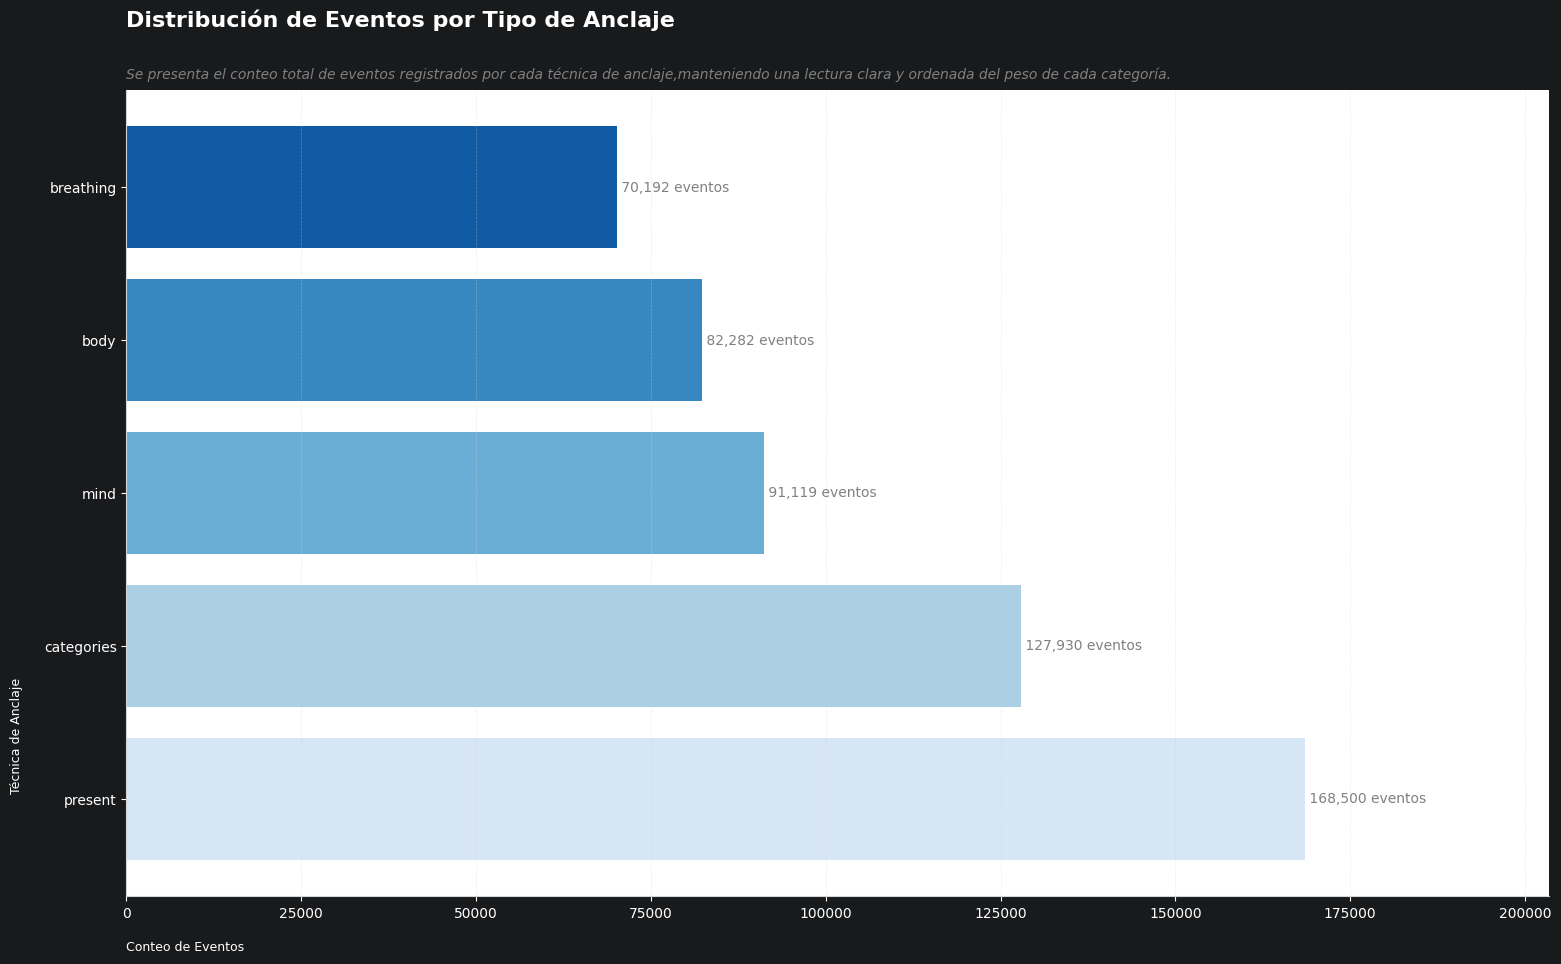

In [88]:
#? 3. Definicion rapida de funciones helper basadas en el trabajo del proyecto final ADM 3080 para decoracion de graficos de plotly y medio semestre ADM 3083 para la funcion de bar chart
#? storytelling de matplotlib

#? 3.1 Definimos los colores para el grafico
COLOR_POSITIVE = '#4A678C'
COLOR_NEGATIVE = '#731A06'
COLOR_WARNING = '#D78019'
COLOR_ATTENTION = '#0C1726'
COLOR_BG = '#F2F2F4'
COLOR_LINE = '#5A5A5C'
COLOR_GREY = '#A4A4A4'
WHITE = '#FFFFFF'
TECHNIQUE_COLORS = {
    'body': '#BA9B65',
    'breathing': '#D9043D',
    'categories': '#025940',
    'mind': '#6F7DA6',
    'present': COLOR_POSITIVE,
}
EVENT_COLORS = {
    'Grounding Started': COLOR_POSITIVE,
    'Grounding Ended': COLOR_NEGATIVE,
}


#? 3.2 Funcion de generate blue pattern de ADM 3083
def generate_blue_palette(n: int) -> _ColorPalette:
    """
    Funcion encargada de generar una paleta de colores replicable en base de la paleta built-in de Blues de Seaborn
    y usando el parametro n para determinar cuantos colores generar y retornar para la visualizacion
    :param n: entero representativo de la cantidad de colores necesarios
    :return: listado de colores
    """
    return sns.color_palette('Blues', n)


#? 3.3 Funcion de dashboard theme de ADM 3080
def apply_dashboard_theme(fig, title: str, subtitle: str, height: int = 700, width: int = 1200):
    """
    Funcion para decorar un grafico de Plotly con un titulo y subtitulo de tipo storytelling con posiciones correctas, etc.
    :param fig:
    :param title:
    :param subtitle:
    :param height:
    :param width:
    :return:
    """
    full_title = f"<b>{title}</b><br><i><span style='font-size:12px;font-weight:200;color:#666'>{subtitle}</span></i>"
    fig.update_layout(
        title={
            'text': full_title,
            'x': 0.02,
            'xanchor': 'left',
            'y': 0.95,
            'font': {'size': 16, 'family': 'Arial'},
        },
        autosize=False,
        width=width,
        height=height,
        margin=dict(l=120, r=120, b=70, t=200, pad=4),
        paper_bgcolor='rgba(0,0,0,0)',
        plot_bgcolor='rgba(0,0,0,0)'
    )
    return fig


#? 3.4 Funcion de ejes de ADM 3080, incluye ambos ejes en una misma funcion
def apply_dashboard_axes(
    fig,
    x_label: str | None = None,
    y_label: str | None = None,
    x_ticks=None,
    x_tick_labels=None,
    x_tick_angle: int = 30,
    x_axis_style: dict | None = None,
    y_axis_style: dict | None = None,
    x_axis_label_distance: float = -0.12,
    y_axis_label_distance: float = -0.12,
):
    default_x_style = {
        'showgrid': False,
        'title': '',
        'showline': True,
        'linewidth': 2,
        'linecolor': COLOR_LINE,
        'tickangle': x_tick_angle,
        'ticks': 'outside',
        'tickwidth': 2,
        'tickcolor': COLOR_LINE,
    }
    default_y_style = {
        'showgrid': False,
        'title': '',
        'showline': True,
        'linewidth': 2,
        'linecolor': COLOR_LINE,
        'ticks': 'outside',
        'tickwidth': 2,
        'tickcolor': COLOR_LINE,
    }

    x_style = default_x_style.copy()
    if x_axis_style:
        x_style.update(x_axis_style)
    if x_ticks is not None:
        x_style['tickvals'] = x_ticks
        x_style['ticktext'] = x_tick_labels if x_tick_labels else [str(t) for t in x_ticks]

    y_style = default_y_style.copy()
    if y_axis_style:
        y_style.update(y_axis_style)

    fig.update_xaxes(x_style)
    fig.update_yaxes(y_style)

    if x_label:
        fig.add_annotation(
            xref='paper',
            yref='paper',
            x=0,
            y=x_axis_label_distance,
            text=x_label,
            showarrow=False,
            xanchor='left',
            yanchor='bottom',
            font=dict(size=12, color=COLOR_LINE, family='Arial Black'),
        )
    if y_label:
        fig.add_annotation(
            xref='paper',
            yref='paper',
            x=y_axis_label_distance,
            y=0,
            text=y_label,
            showarrow=False,
            textangle=-90,
            xanchor='left',
            yanchor='bottom',
            font=dict(size=12, color=COLOR_LINE, family='Arial Black'),
        )
    return fig

#? 3.5 Funcion de ADM 3083 para creacion de un bar chart con storytelling
def crear_barchart_storytelling(
        data: pd.DataFrame,
        x_axis_data: Any | str | pd.Series,
        x_axis_title: str,
        y_axis_data: Any | str | pd.Series,
        y_axis_title: str,
        fig_size: tuple[int, int],
        color_palette: Any,
        title: str,
        subtitle: str,
        orientation: str = 'horizontal',
        grid_axis: str = 'x',
        grid_color: str = 'lightgray',
        grid_linestyle: str = '--',
        grid_alpha: float = 0.4,
        visible_spines: set[str] = None,
        spine_colors: dict[str, str] = None,
        show_bar_labels: bool = True,
        bar_label_offset: float = 10,
        bar_label_fontsize: int = 10,
        bar_label_color: str = 'gray',
        bar_label_formatter: callable = None,
        hue: str = None,
        hue_order: list[str] = None,
        order: list[str] = None,
        show_x_axis: bool = True,
        show_y_axis: bool = True,
        x_tick_rotation: float = 0,
        y_tick_rotation: float = 0,
        show_legend: bool = False,
        legend_position: str = 'best',
        legend_title: str = None
) -> tuple[plt.Figure, plt.Axes]:
    """
    Funcion diseñada para generar una visualizacion orientada al storytelling con un titulo centrado, subtitulo con insight, y
    data programable para evitar la reescritura del codigo de las visualizaciones.
    """

    if visible_spines is None:
        visible_spines = {'bottom', 'left'}
    if spine_colors is None:
        spine_colors = {'bottom': 'lightgray', 'left': 'lightgray'}
    if bar_label_formatter is None:
        bar_label_formatter = lambda v: f'{v:,.0f}'

    fig, ax = plt.subplots(figsize=fig_size)
    if orientation == 'horizontal':
        if hue is not None:
            bars = sns.barplot(
                data=data,
                y=y_axis_data,
                x=x_axis_data,
                hue=hue,
                order=order,
                hue_order=hue_order,
                palette=color_palette,
                ax=ax,
            ).patches
        else:
            bars = ax.barh(data[y_axis_data], data[x_axis_data], color=color_palette)
    else:
        if hue is not None:
            bars = sns.barplot(
                data=data,
                x=x_axis_data,
                y=y_axis_data,
                hue=hue,
                order=order,
                hue_order=hue_order,
                palette=color_palette,
                ax=ax,
            ).patches
        else:
            bars = ax.bar(data[x_axis_data], data[y_axis_data], color=color_palette)

    ax.set_facecolor('white')
    ax.set_title(title, fontsize=16, fontweight='bold', loc='left', pad=45)
    ax.text(
        0.0,
        1.01,
        subtitle,
        transform=ax.transAxes,
        fontsize=10,
        fontstyle='italic',
        color='gray',
        va='bottom',
        ha='left'
    )

    if x_axis_title is not None and isinstance(x_axis_title, str):
        ax.set_xlabel(x_axis_title, fontdict={'fontsize': 9, 'fontweight': 'normal'}, labelpad=15, ha='left', x=0)
    if y_axis_title is not None and isinstance(y_axis_title, str):
        ax.set_ylabel(y_axis_title, fontdict={'fontsize': 9, 'fontweight': 'normal'}, labelpad=15, ha='center', va='bottom', y=0.2)

    if grid_axis == 'none':
        ax.grid(False)
    elif grid_axis == 'both':
        ax.grid(True, color=grid_color, linestyle=grid_linestyle, alpha=grid_alpha)
    else:
        ax.grid(False)
        ax.grid(True, axis=grid_axis, color=grid_color, linestyle=grid_linestyle, alpha=grid_alpha)

    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(spine in visible_spines)
        if spine in spine_colors:
            ax.spines[spine].set_color(spine_colors[spine])

    ax.xaxis.set_visible(show_x_axis)
    ax.yaxis.set_visible(show_y_axis)

    if x_tick_rotation != 0:
        ax.tick_params(axis='x', rotation=x_tick_rotation)
    if y_tick_rotation != 0:
        ax.tick_params(axis='y', rotation=y_tick_rotation)

    if show_bar_labels:
        if orientation == 'horizontal':
            ax.set_xlim(right=ax.get_xlim()[1] * 1.15)
        else:
            ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

        for bar in bars:
            if orientation == 'horizontal':
                width = bar.get_width()
                if width != 0:
                    ax.text(
                        width,
                        bar.get_y() + bar.get_height() / 2,
                        bar_label_formatter(width),
                        color=bar_label_color,
                        va='center',
                        fontsize=bar_label_fontsize,
                    )
            else:
                height = bar.get_height()
                if height != 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        height,
                        bar_label_formatter(height),
                        color=bar_label_color,
                        ha='center',
                        fontsize=bar_label_fontsize,
                        va='bottom',
                    )

    if show_legend and hue is not None:
        ax.legend(title=legend_title, loc=legend_position)
    elif not show_legend:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()

    plt.tight_layout(pad=2.0)
    plt.show()


#? 3.6 Definimos los datos que vamos a usar para el conteo de eventos por tecnica de anclaje
result = data_as_is['techniqueID'].value_counts().T.to_frame()
result = data_as_is['techniqueID'].value_counts().T.to_frame()
result.loc['Total',:] = result.sum(axis=0)

result_reset = result.drop(index='Total').reset_index().rename(columns={'techniqueID': 'Técnica'})
colors = generate_blue_palette(len(result_reset))

crear_barchart_storytelling(
    data=result_reset,
    y_axis_data='Técnica',
    x_axis_data='count',
    x_axis_title='Conteo de Eventos',
    y_axis_title='Técnica de Anclaje',
    show_y_axis=True,
    show_x_axis=True,
    bar_label_formatter=lambda v: f' {int(v):,.0f} eventos ',
    fig_size=(16, 10),
    color_palette=colors,
    orientation='horizontal',
    title='Distribución de Eventos por Tipo de Anclaje',
    subtitle='Se presenta el conteo total de eventos registrados por cada técnica de anclaje,'
             'manteniendo una lectura clara y ordenada del peso de cada categoría.'
)


En este caso notamos que la mayoría de los eventos del dataset se concentran directamente en tres técnicas de anclaje siendo estas **present, categories y mind** mientras que **body y breathing** son las clases con menores conteos de registros de todo el dataset. En paralelo con esta distribución, es importante notar qeu las categorías más altas, especificamente **present** corresponde a aquella categoría con mayor cantidad de registros de terminación que inicio, lo que indica que la categoría está modificando los datos de eventos iniciados por usuarios dado que aparece en varios registros adicionales o duplicados, lo que puede afectar la precisión y confiabilidad de los resultados obtenidos a partir de estos datos. Por otro lado, las categorías con menor cantidad de registros, específicamente **body y breathing** corresponden a aquellas categorías con mayor cantidad de registros de inicio que terminación, lo que indica que estas categorías están modificando los datos de eventos terminados por usuarios dado que aparecen en varios registros adicionales o huérfanos, lo que también puede afectar la precisión y confiabilidad de los resultados obtenidos a partir de estos datos.

En general, el registro de datos se ve afectado mayoritariamente por este error de registro de datos correspondiente a la paridad de inicio y fin de actividades, dado que al tener sea más inicios o más finalizaciones, los datos de esas categorías de anclaje presentan en el dataset una representación que no es real, dado que los datos se han inflado en cualquier dirección afectando la veracidad de los datos.

#### Exploración de date

Para esta sección, exploraremos los registros mediante una conversión en data to explore basado en la transformación de la columna de date a dos columnas, una para fecha y otra para hora, y luego de esto explorar la distribución de horas y la distribución de fechas. Luego usaremos estos datos para realizar un análisis de conteo basado en la distribución de  los eventos de terminación e inicio de event, y los tipos de anclaje por horas del día, por día y por semana.


Para esta subseccion se trabaja sobre una copia del dataset para no alterar los datos originales. Primero se separa la columna date en campos base y luego se construyen tres agregaciones: por fecha, por hora y por dia de semana.


In [57]:
#? 1. Convertimos date a datetime y derivamos campos base para analisis

# Definimos date_dt que es la columna de datetime que tiene el formato y todo el dato original de la fecha
data_to_explore['date_dt'] = pd.to_datetime(data_to_explore['date'], format='%m/%d/%Y %H:%M', errors='coerce')

# Obtenemos la fecha sola, la hora el anio el numero del mes y el nombre del mes basado en un mapeo
data_to_explore['fecha'] = data_to_explore['date_dt'].dt.date
data_to_explore['hora'] = data_to_explore['date_dt'].dt.hour
data_to_explore['anio'] = data_to_explore['date_dt'].dt.year
data_to_explore['mes_num'] = data_to_explore['date_dt'].dt.month
data_to_explore['nombre_mes'] = data_to_explore['mes_num'].map(
    {1: 'Enero',
     2: 'Febrero',
     3: 'Marzo',
     4: 'Abril',
     5: 'Mayo',
     6: 'Junio',
     7: 'Julio',
     8: 'Agosto',
     9: 'Septiembre',
     10: 'Octubre',
     11: 'Noviembre',
     12: 'Diciembre'})

# Obtenemos el dia de la semana y el nombre para analisis posterior
data_to_explore['dia_semana_num'] = data_to_explore['date_dt'].dt.dayofweek
data_to_explore['dia_semana'] = data_to_explore['dia_semana_num'].map(
    {
        0: 'Lunes',
        1: 'Martes',
        2: 'Miercoles',
        3: 'Jueves',
        4: 'Viernes',
        5: 'Sabado',
        6: 'Domingo'})

data_to_explore


,Unnamed: 0,id,event,techniqueID,date,date_dt,fecha,hora,anio,mes_num,nombre_mes,dia_semana_num,dia_semana
0,1,2719,Grounding Started,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,Enero,2,Miercoles
1,2,2720,Grounding Ended,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,Enero,2,Miercoles
2,3,2721,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,Enero,2,Miercoles
3,4,2722,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,Enero,2,Miercoles
4,5,2723,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,Enero,2,Miercoles
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540018,1323286,1326004,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,Marzo,2,Miercoles
540019,1323287,1326005,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,Marzo,2,Miercoles
540020,1323292,1326010,Grounding Ended,categories,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,Marzo,2,Miercoles
540021,1323299,1326017,Grounding Started,body,3/16/2022 16:46,2022-03-16 16:46:00,2022-03-16,16,2022,3,Marzo,2,Miercoles


In [58]:
#? 2. Agregamos los eventos por fecha para ver la carga diaria
agrupacion_fecha = data_to_explore.groupby(['fecha', 'event']).size().unstack(fill_value=0).sort_index()
agrupacion_fecha['Total'] = agrupacion_fecha.sum(axis=1)
agrupacion_fecha.sort_values('Total', ascending=False).head(10)


event,Grounding Ended,Grounding Started,Total
fecha,,,
2022-01-23,9298,9319,18617
2022-01-24,7552,7615,15167
2022-01-25,6668,6716,13384
2022-01-22,5689,5674,11363
2022-01-26,5618,5552,11170
2022-03-07,5249,5138,10387
2022-03-06,5178,5134,10312
2022-01-27,4938,4800,9738
2022-02-07,4726,4701,9427


In [87]:
#? 3. Visualizacion con Plotly de la agrupacion por fecha con drill-down Month -> Day -> Hour: esta visualizacion fue creada con ayuda de la inteligencia artifical de
#? Amazon Q basada en el modelo de Claude Sonnet 4.5


#? 3.1 Agrupamos por fechas
agrupacion_fecha_plot = agrupacion_fecha.reset_index().melt(
    #? id_vars hace referencia  la columna de tipo ancla, al indice que no se mueve como un pivote en los datos
    #? value_vars son las columnas que se hacen un stacking, es decir de un formato largo como tiene la tabla original conlos eventos de terminacion e inicio como columnas regresamos a un stack de eventos.
    #? var_name es el nombre de esta nueva columna que se va a crear con el nombre de los eventos, y value_name es el nombre de la columna que se va a crear con el conteo de eventos para cada fecha y evento.
    id_vars='fecha', value_vars=['Grounding Started', 'Grounding Ended'],
    var_name='event', value_name='conteo'
)
print(f"{'Head (5) agrupacion de fechas':=^120}")
print(agrupacion_fecha_plot.head(5))

#? 3.2 Mandamos a fecha al indice para generar data en una serie de tiempo
agrupacion_fecha_plot['fecha'] = pd.to_datetime(agrupacion_fecha_plot['fecha'])

#? 3.3 Preparar las tres agregaciones
# Agregamos por mes defiiendo un periodo de meses, tomando en cuenta el mes de cada registeo en base al indice de fecha
mes_df = agrupacion_fecha_plot.copy()
mes_df['periodo'] = mes_df['fecha'].dt.to_period('M').dt.to_timestamp()
mes_agg = mes_df.groupby(['periodo', 'event'])['conteo'].sum().reset_index()
mes_agg['label'] = mes_agg['periodo'].dt.strftime('%B %Y') #Esta label incluye en nombre del mes y el anio general

# Agregamos por dia con el mismo contexto que por mes, pero en base a dias con .normalize()
dia_df = agrupacion_fecha_plot.copy()
dia_df['periodo'] = dia_df['fecha'].dt.normalize()
dia_agg = dia_df.groupby(['periodo', 'event'])['conteo'].sum().reset_index()
dia_agg['label'] = dia_agg['periodo'].dt.strftime('%d %b %Y') #Mostramos dia, mes y anio

# Hora (si la fecha original tiene componente horario, se agrupa por hora)
hora_df = agrupacion_fecha_plot.copy()
hora_df['periodo'] = hora_df['fecha'].dt.floor('h')
hora_agg = hora_df.groupby(['periodo', 'event'])['conteo'].sum().reset_index()
hora_agg['label'] = hora_agg['periodo'].dt.strftime('%d %b %Y %H:%M') #Mostramos dia mes anio  hora

events = ['Grounding Started', 'Grounding Ended']
fig = go.Figure()

#? 3.4 Agregar traces para cada nivel: 0-1 = mes, 2-3 = dia, 4-5 = hora
for i, (agg, level) in enumerate([(mes_agg, 'mes'), (dia_agg, 'dia'), (hora_agg, 'hora')]):
    for event in events:
        event_data = agg[agg['event'] == event].sort_values('periodo')
        fig.add_trace(go.Scatter(
            x=event_data['label'],
            y=event_data['conteo'],
            mode='lines+markers',
            name=event,
            legendgroup=event,
            showlegend=True,
            visible=(i == 0), #SOlo dejamos visible la capa de trazas para meses como el nivel de agregacion base
            line=dict(color=EVENT_COLORS.get(event)),
            marker=dict(color=EVENT_COLORS.get(event)),
            hovertemplate='%{x}<br>%{y:,.0f} eventos<extra>' + event + '</extra>',
        ))


#? 3.5 Definir visibilidad por nivel (2 traces por nivel x 3 niveles = 6 traces) y botones para cambiar entre niveles
def make_visibility(active_level):
    vis = [False] * 6
    base = active_level * 2
    vis[base] = True
    vis[base + 1] = True
    return vis

fig.update_layout(
    updatemenus=[
        dict(
            type='buttons',
            direction='right',
            x=0.5, xanchor='center',
            y=-0.15, yanchor='top',
            buttons=[
                dict(label='▶ Mes', method='update',
                     args=[{'visible': make_visibility(0)},
                           {'xaxis': {'title': 'Mes', 'showgrid': False, 'showline': True,
                                      'linecolor': COLOR_LINE, 'linewidth': 2,
                                      'ticks': 'outside', 'tickcolor': COLOR_LINE}}]),
                dict(label='▶ Día', method='update',
                     args=[{'visible': make_visibility(1)},
                           {'xaxis': {'title': 'Día', 'showgrid': False, 'showline': True,
                                      'linecolor': COLOR_LINE, 'linewidth': 2,
                                      'ticks': 'outside', 'tickcolor': COLOR_LINE,
                                      'tickangle': -45}}]),
                dict(label='▶ Hora', method='update',
                     args=[{'visible': make_visibility(2)},
                           {'xaxis': {'title': 'Hora', 'showgrid': False, 'showline': True,
                                      'linecolor': COLOR_LINE, 'linewidth': 2,
                                      'ticks': 'outside', 'tickcolor': COLOR_LINE,
                                      'tickangle': -45}}]),
            ],
        )
    ],
)

#? 3.6 Aplicamos el estado similar al de toda la dashboard
apply_dashboard_theme(
    fig,
    'Conteo por fecha y evento',
    'Durante el analisis se muestra una temporalidad en donde la tendencia entre los eventos iniciados y terminados son generalmente similares.<br>'
    'En la vision por mes, notamos que los inicios y terminaciones de sesion se mueven en un patron similar, msostrando un crecimiento hasta febrero, con un decreimiento abrupto en marzo.<br>'
    'Al realizar drilldowns en dia u hora, notamos un patron similar donde la distancia entre las lineas,y por ende entre inicios y terminaciones de sesion es baja',
    height=700,
)
apply_dashboard_axes(fig, x_label='Mes', y_label='Conteo de eventos', x_tick_angle=0, y_axis_style={'tickformat': ',.0f'})
fig.update_layout(
    hovermode='x unified',
    legend=dict(title='Evento', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    margin=dict(b=120),
    yaxis_zeroline=False
)
fig.show()


=============================================Head (5) agrupacion de fechas==============================================
        fecha              event  conteo
0  2021-12-17  Grounding Started       9
1  2021-12-21  Grounding Started       1
2  2022-01-11  Grounding Started       1
3  2022-01-12  Grounding Started     605
4  2022-01-13  Grounding Started    2736


In [60]:
#? 3. Agregamos los eventos por hora para detectar concentracion intradia
agrupacion_hora = data_to_explore.groupby(['hora', 'event']).size().unstack(fill_value=0).sort_index()
agrupacion_hora['Total'] = agrupacion_hora.sum(axis=1)
agrupacion_hora


event,Grounding Ended,Grounding Started,Total
hora,,,
0,20193,19476,39669
1,14595,14597,29192
2,9138,9236,18374
3,4519,4495,9014
4,2781,2952,5733
5,2316,2377,4693
6,2664,2740,5404
7,3865,3994,7859
8,5288,5094,10382


In [61]:
#? 4. Visualizacion con Plotly de la agrupacion por hora y la tasa de eventos de inicio y fin


#? 4.1 Ahora realizamos el mismo estilo de stacking de casos, pero en lugar de trabajar mediante la agrupacion por fecha, tomamos directamente la agregacion por horas
agrupacion_hora_plot = (
    agrupacion_hora
        .reset_index()
        .melt(
            id_vars='hora', #Columna de eje, la hora del dataset agrupado por hora
            value_vars=['Grounding Started', 'Grounding Ended'], #columans de valores a hacer un melt por cada registro de hora
            var_name='event', #nombre de la columna de agregacion de eventos
            value_name='conteo' #nombre de la columna final con los valores
        )
)

#? 4.2 Definimos un grafico de barras qeu compare en el eje x las horas del dia y en el eje y el conteo de cada una de los eventos, sea de inicio o de fin segmentado por los colores de evento
fig = px.bar(
    agrupacion_hora_plot,
    x='hora',
    y='conteo',
    color='event',
    barmode='group',
    category_orders={'hora': list(range(24))},
    color_discrete_map=EVENT_COLORS,
    title='Conteo por hora y evento'
)

#? 4.3 Configuramos con el estilo general de todas las dashboards
apply_dashboard_theme(
    fig,
    'Conteo por hora y evento',
    'Durante el periodo de analisis y todo el dataset, los datos demuestran una estacionalidad temporal dentro de cada dia de la semana, donde en promedio<br>'
    'los inicios de sesion tinenden a acumularse desde las 20:00 PM hasta altas horas de la madrugada como las 02:00 AM, mientras que las sesiones durante el dia caen drasticamente<br>'
    'durante la manana y tienen un repunte que dura toda la tarde hasta el crecimiento acelerado a las 20:00 PM',
    height=900,
)
apply_dashboard_axes(fig, x_label='Hora del día', y_label='Conteo de eventos', x_ticks=list(range(24)), x_tick_labels=[f"{str(h)} H" for h in range(24)], x_tick_angle=0, y_axis_style={'tickformat': ',.0f'})
fig.update_layout(hovermode='x', legend=dict(title='Evento', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1), height=1000)


In [62]:
#? 5. Agregamos los eventos por dia de la semana para ver patrones semanales

#? 5.1 Definimos el orden de los dias general para su trabajo en el grafico
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']

#? 5.2 Agrupamos por dia de la semana y realizmamos el conteo de eventos
agrupacion_dia_semana = (
    data_to_explore
        .groupby(
            by=['dia_semana', 'event']
        )
        .size()
        .unstack(fill_value=0) #Hacemos un unstack para tener en formato ancho no en formato largo
        .reindex(orden_dias)  #Hacemos una reindexacion correspondiente al orden de los dias para el axis
        .fillna(0)
        .astype(int)
)

agrupacion_dia_semana['Total'] = agrupacion_dia_semana.sum(axis=1)
agrupacion_dia_semana


event,Grounding Ended,Grounding Started,Total
dia_semana,,,
Lunes,42174,41359,83533
Martes,39858,39000,78858
Miercoles,37043,36574,73617
Jueves,36397,35655,72052
Viernes,35563,35022,70585
Sabado,37385,36590,73975
Domingo,44067,43336,87403


In [102]:
#? 6. Visualizacion con Plotly de la agrupacion por dia de la semana con el conteo de eventos por cada dia
agrupacion_dia_semana_plot = agrupacion_dia_semana.reset_index().melt(id_vars='dia_semana', value_vars=['Grounding Started', 'Grounding Ended'], var_name='event', value_name='conteo')


#? 6.1 Definimos un grafico de barras en un estilo similar al de horas, agrupando por el tipo de evento y definiendo un color discreto basado en el evento
fig = px.bar(
    agrupacion_dia_semana_plot,
    x='dia_semana',
    y='conteo',
    color='event',
    barmode='group',
    category_orders={'dia_semana': orden_dias},
    color_discrete_map=EVENT_COLORS,
    title='Conteo por dia de la semana y evento'
)

#? 6.2 Definimos un color y estilo estandar
apply_dashboard_theme(
    fig,
    'Conteo por día de la semana y evento',
    'Durante el periodo de analisis, la distribucion semanal muestra que los Lunes y los Domingos tienen la mayor cantidad de sesiones iniciadas, y como es comun para todo el dataset<br>'
    'un numero similar de terminaciones de sesion que supera a la cantidad de sesiones iniciadas por la estructura intrinsica del dataset.',
    height=650
)
apply_dashboard_axes(fig, x_label='Día de la semana', y_label='Conteo de eventos', x_tick_angle=0, y_axis_style={'tickformat': ','})
fig.update_layout(hovermode='x', legend=dict(title='Evento', orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1))
fig.show()


In [64]:
#? 7. Agrupamos por mes y techniqueID para contar eventos por tipo
orden_meses = ['Enero', 'Febrero', 'Marzo', 'Abril', 'Mayo', 'Junio', 'Julio', 'Agosto', 'Septiembre', 'Octubre', 'Noviembre', 'Diciembre']
agrupacion_mes = (
    data_to_explore
        .groupby(
            by=['mes_num', 'nombre_mes', 'techniqueID', 'event']
        )
        .size()
        .unstack(fill_value=0)
        .reset_index()
        .sort_values(
            ['mes_num', 'techniqueID']
        )
)
agrupacion_mes


event,mes_num,nombre_mes,techniqueID,Grounding Ended,Grounding Started
0,1,Enero,body,11870,17127
1,1,Enero,breathing,10494,13062
2,1,Enero,categories,14616,29859
3,1,Enero,mind,12095,18889
4,1,Enero,present,45351,12812
5,2,Febrero,body,13563,20183
6,2,Febrero,breathing,12899,16434
7,2,Febrero,categories,17102,36001
8,2,Febrero,mind,15163,23266
9,2,Febrero,present,53913,15505


In [65]:
#? 8. Visualizacion con Plotly de la agrupacion por mes y techniqueID
agrupacion_mes_plot = agrupacion_mes.melt(
    id_vars=['mes_num', 'nombre_mes', 'techniqueID'],
    value_vars=['Grounding Started', 'Grounding Ended'],
    var_name='event', value_name='conteo'
)

#? 8.1 Filtrar solo hasta marzo (mes_num <= 3)
agrupacion_mes_plot = agrupacion_mes_plot[agrupacion_mes_plot['mes_num'] <= 3]
orden_meses_filtrado = [m for m in orden_meses if m in agrupacion_mes_plot['nombre_mes'].values]


#? 8.2 Definimos los subplots en donde vamos a trabajar
events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_mes_plot['techniqueID'].unique()
shown_legends = set()

#? 8.3 Iteramos sobre todos los eventos para obtener los detalles del conteo de cada evento donde mantenemos informacion de tecnicas y messe
for col_idx, event in enumerate(events, start=1):
    event_data = agrupacion_mes_plot[agrupacion_mes_plot['event'] == event]
    #? 8.3.1 Por cada tecnica, extrameos la data de esa tecnica directamente y anadimos el grafico de barras con un eje x de los mese, y el conteo y segmentado por el el color de
    #? la tecnica
    for tech in techniques:
        tech_data = (event_data[event_data['techniqueID'] == tech]
                     .set_index('nombre_mes')
                     .reindex(orden_meses_filtrado)
                     .reset_index())
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Bar(
                x=tech_data['nombre_mes'],
                y=tech_data['conteo'],
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                marker_color=TECHNIQUE_COLORS.get(tech),
            ),
            row=1, col=col_idx
        )

#? 8.4 Definimos estilos adicionales
fig.update_layout(barmode='group')
apply_dashboard_theme(
    fig,
    'Conteo por mes, techniqueID y evento',
    'Durante el periodo de analisis, notamos que para cada mes del dataset, <b>categories</b> tiene el pico mas alto de inicios de sesion, mientras que <b>present</b> presenta la mayor<br>'
    'cantidad de terminaciones de eventos. Si bien la mayoria de las categorias se mueven en el patron general del dataset, con mas inicios de sesion que terminaciones, para<br><b>categories</b> la historia es mas drastica, donde en cada mes, los inicios de sesiones son el doble de las cancelaciones, mostrando una categoria en donde casi 1 de cada 2<br> sesiones nunca se marcan como terminadas. Por otro lado, para <code>present</code> la relacion muestra que las termianciones se registran en promedio tres veces mas<br>que los inicios de sesion',
    height=680,
)
fig.update_layout(legend_title='Técnica', hovermode='closest')
fig.update_xaxes(title='Mes', showgrid=False, showline=True, linecolor=COLOR_LINE, linewidth=2, ticks='outside', tickcolor=COLOR_LINE)
fig.update_yaxes(title='Conteo', showgrid=False, showline=True, linecolor=COLOR_LINE, linewidth=2, ticks='outside', tickcolor=COLOR_LINE, tickformat=',.0f')
fig.show()


Durante el periodo de análisis, observamos un comportamiento claramente diferenciado entre los tipos de técnicas registradas. Al desglosar el conteo mensual por techniqueID y por tipo de evento (<i>Grounding Startedy Grounding Ended</i>), se evidencia que <code>categories</code> concentra de manera consistente el mayor número de inicios de sesión en cada uno de los meses del dataset. Este patrón se mantiene sin excepción, alcanzando picos particularmente altos en febrero.

En contraste, cuando analizamos los eventos de finalización, la técnica <code>present</code> se posiciona como la que registra la mayor cantidad de sesiones terminadas mes a mes. Esto sugiere que, aunque no sea la técnica más iniciada, sí es la que logra cerrar más actividades, lo que podría interpretarse como una mayor efectividad o un mayor nivel de compromiso por parte de los usuarios que la seleccionan. Por otro lado, esta relación podría interpretarse como un error dentro del sistema de registro de actividades, si tenemos en cuenta una noción de evento iniciado a finalizado como el Customer Journey que la empresa trata de mantener, si pensamos en que las interrupciones pueden deberse a situaciones externas de la aplicación, desinterés del usuario, u otros efectos externos que pueden estar siendo registrados como terminaciones cuando pueden ser timeouts, tenemos una cuenta que muestra un error sistemático en la recopilación de datos.

Si bien la mayoría de las técnicas siguen la tendencia general del dataset,es decir, presentan más inicios que terminaciones, el caso de <code>categories</code> es especialmente llamativo. En cada mes analizado, los inicios de sesión para esta técnica duplican sistemáticamente el número de finalizaciones. Esto implica que casi 1 de cada 2 sesiones iniciadas en categories no llega a marcarse como terminada, lo que abre la puerta a posibles hipótesis sobre fricción en la experiencia, desinterés del usuario o interrupciones frecuentes durante este tipo de ejercicio.

Por otro lado, en el caso de <code>present</code>, la relación entre inicios y terminaciones es mucho más equilibrada, e incluso favorable en términos de cierre. Esto sugiere un flujo de uso más estable y una mayor probabilidad de que los usuarios completen la actividad una vez que la han comenzado, si tomamos en cuenta que todos los registros son validos para sesiones qe no se han tomado en cuenta dentro del dataset, sino, la historia que muestran es de registros erroneos


In [66]:
#? 9. Agrupamos por dia de la semana y techniqueID para contar eventos por tipo
orden_dias = ['Lunes', 'Martes', 'Miercoles', 'Jueves', 'Viernes', 'Sabado', 'Domingo']
agrupacion_dia_semana_tech = data_to_explore.groupby(['dia_semana_num', 'dia_semana', 'techniqueID', 'event']).size().unstack(fill_value=0).reset_index().sort_values(['dia_semana_num', 'techniqueID'])
agrupacion_dia_semana_tech


event,dia_semana_num,dia_semana,techniqueID,Grounding Ended,Grounding Started
0,0,Lunes,body,5096,7580
1,0,Lunes,breathing,4830,6073
2,0,Lunes,categories,6239,13370
3,0,Lunes,mind,5595,8518
4,0,Lunes,present,20414,5818
5,1,Martes,body,4801,7188
6,1,Martes,breathing,4493,5701
7,1,Martes,categories,6138,12601
8,1,Martes,mind,5235,8035
9,1,Martes,present,19191,5475


In [67]:
#? 10. Visualizacion con Plotly de la agrupacion por dia de la semana y techniqueID
agrupacion_dia_semana_tech_plot = agrupacion_dia_semana_tech.melt(
    id_vars=['dia_semana_num', 'dia_semana', 'techniqueID'],
    value_vars=['Grounding Started', 'Grounding Ended'],
    var_name='event', value_name='conteo'
)

events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_dia_semana_tech_plot['techniqueID'].unique()
shown_legends = set()

for col_idx, event in enumerate(events, start=1):
    event_data = agrupacion_dia_semana_tech_plot[agrupacion_dia_semana_tech_plot['event'] == event]
    for tech in techniques:
        tech_data = event_data[event_data['techniqueID'] == tech].set_index('dia_semana').reindex(orden_dias).reset_index()
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Scatter(
                x=tech_data['dia_semana'],
                y=tech_data['conteo'],
                mode='lines+markers',
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                line=dict(color=TECHNIQUE_COLORS.get(tech)),
            ),
            row=1, col=col_idx
        )

apply_dashboard_theme(
    fig,
    'Conteo por día de la semana, techniqueID y evento',
    'Durante el periodo de analisis, notamos que todas las tecnicas tienen un repunte de inicio de sesiones enre el Lunes y Domingo, mientras que el resto de la semana muestra un<br>'
    'decrecimiento paulatino en el inicio de sesione, donde una imagen paralela afecta a la finalizaciion de sesiones',
    height=680,
)
fig.update_layout(legend_title='Técnica', hovermode='closest')
fig.update_xaxes(title='Día de la semana', showgrid=False, showline=True, linecolor=COLOR_LINE, linewidth=2, ticks='outside', tickcolor=COLOR_LINE)
fig.update_yaxes(title='Conteo', showgrid=False, showline=True, linecolor=COLOR_LINE, linewidth=2, ticks='outside', tickcolor=COLOR_LINE, tickformat=',.0f')
fig.show()


Durante el periodo de análisis, se observa un patrón semanal marcado en el comportamiento de las técnicas de grounding. En los eventos de inicio de sesión, la técnica **categories** destaca con los mayores picos, especialmente los días lunes y domingo, donde alcanza cifras significativamente superiores al resto. El resto de las técnicas mantiene un nivel más estable, con valores intermedios que oscilan entre semana, pero sin alcanzar la magnitud de categories.

En cuanto a los eventos de finalización, la técnica **present** se posiciona como la más consistente y dominante, registrando los mayores conteos también en lunes y domingo. Esto refleja que, aunque no sea la técnica más iniciada, sí logra cerrar más sesiones, lo que sugiere un mayor nivel de compromiso o efectividad en la experiencia del usuario.

El patrón general muestra que tanto los inicios como las terminaciones tienden a concentrarse al inicio y al final de la semana, mientras que los días intermedios presentan un descenso progresivo. Esta dinámica podría indicar que los usuarios recurren a estas técnicas en momentos de transición, al comenzar la semana y al cerrarla, lo que abre oportunidades para diseñar estrategias de acompañamiento o campañas que refuercen el uso en los días de menor actividad.

## Sección III: Preprocesamiento de Datos Iniciales

En esta sección se trabajará para aplicar las medidas de limpieza de datos definidas en la sección I, aplicando las correcciones necesarias para el análisis, como la eliminación de columnas no útiles, la derivación de columnas adicionales para el análisis, y la corrección de valores atípicos o nulos en base a las métricas definidas en la sección I.

In [68]:
#? 1. Eliminamos columnas de identificación que no aportan valor analítico
columnas_a_eliminar = ['Unnamed: 0', 'id']
data_cleaned = data_cleaned.drop(columns=columnas_a_eliminar, errors='ignore')


In [69]:
#? 2. Convertimos la columna `date` a datetime para derivar atributos temporales
#? El formato observado en el cuaderno es mm/dd/yyyy hh:mm
data_cleaned['date_dt'] = pd.to_datetime(
    data_cleaned['date'],
    format='%m/%d/%Y %H:%M',
    errors='coerce'
)

dias_semana_es = {
    0: 'lunes',
    1: 'martes',
    2: 'miércoles',
    3: 'jueves',
    4: 'viernes',
    5: 'sábado',
    6: 'domingo',
}
meses_es = {
    1: 'enero',
    2: 'febrero',
    3: 'marzo',
    4: 'abril',
    5: 'mayo',
    6: 'junio',
    7: 'julio',
    8: 'agosto',
    9: 'septiembre',
    10: 'octubre',
    11: 'noviembre',
    12: 'diciembre',
}

#? 2.1 Derivamos las columnas temporales solicitadas
#? `fecha` mantiene solo la fecha; `hora` conserva la hora del evento
#? y el resto de columnas facilitan agregaciones por mes y día de semana
data_cleaned['fecha'] = data_cleaned['date_dt'].dt.date
data_cleaned['hora'] = data_cleaned['date_dt'].dt.hour.astype('Int64')
data_cleaned['anio'] = data_cleaned['date_dt'].dt.year.astype('Int64')
data_cleaned['mes_num'] = data_cleaned['date_dt'].dt.month.astype('Int64')
data_cleaned['nombre_mes'] = data_cleaned['mes_num'].map(meses_es)
data_cleaned['dia_semana_num'] = data_cleaned['date_dt'].dt.dayofweek.astype('Int64')
data_cleaned['dia_semana'] = data_cleaned['dia_semana_num'].map(dias_semana_es)

data_cleaned


,event,techniqueID,date,date_dt,fecha,hora,anio,mes_num,nombre_mes,dia_semana_num,dia_semana
0,Grounding Started,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,enero,2,miércoles
1,Grounding Ended,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,enero,2,miércoles
2,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles
3,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles
4,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles
...,...,...,...,...,...,...,...,...,...,...,...
540018,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles
540019,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles
540020,Grounding Ended,categories,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles
540021,Grounding Started,body,3/16/2022 16:46,2022-03-16 16:46:00,2022-03-16,16,2022,3,marzo,2,miércoles


In [70]:
#? 3. Aplicamos One-hot encoding de `event`.
#? Se conservan las columnas originales para no romper el análisis posterior,
#? pero se agregan variables binarias para facilitar agrupaciones y cruces.
event_dummies = pd.get_dummies(data_cleaned['event'], dtype='int64')
data_cleaned = pd.concat([data_cleaned, event_dummies], axis=1)

data_cleaned


,event,techniqueID,date,date_dt,fecha,hora,anio,mes_num,nombre_mes,dia_semana_num,dia_semana,Grounding Ended,Grounding Started
0,Grounding Started,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,enero,2,miércoles,0,1
1,Grounding Ended,present,1/12/2022 14:06,2022-01-12 14:06:00,2022-01-12,14,2022,1,enero,2,miércoles,1,0
2,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles,1,0
3,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles,1,0
4,Grounding Ended,present,1/12/2022 14:07,2022-01-12 14:07:00,2022-01-12,14,2022,1,enero,2,miércoles,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540018,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles,1,0
540019,Grounding Ended,present,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles,1,0
540020,Grounding Ended,categories,3/16/2022 16:45,2022-03-16 16:45:00,2022-03-16,16,2022,3,marzo,2,miércoles,1,0
540021,Grounding Started,body,3/16/2022 16:46,2022-03-16 16:46:00,2022-03-16,16,2022,3,marzo,2,miércoles,0,1


## Sección IV: Análisis de Datos

En esta sección se trabajará con un análisis de datos en base de agrupaciones y visualizaciones para identificar patrones y responder a las preguntas de negocio. Dado que no tenemos una cantidad significativa de datos numéricos para realizar un análisis estadísticos, se considerará, con vista a los resultados de agregaciones y visualizaciones la posibilidad de realizar pruebas de hipótesis estadísticas para evaluar la significancia de los resultados obtenidos, lo que podría ser útil para identificar patrones significativos en los datos y evitar conclusiones erróneas basadas en patrones aleatorios o ruido en los datos.

### Frecuencia de Uso de Cada Técnica de Anclaje

In [71]:
#? 1. Exploracion de la distribucion de eventos de inicio y finalizacion por cada tipo de anclaje
result = data_as_is.groupby(by='techniqueID')['event'].value_counts(sort=True)


conteo_y_proporcion_de_eventos_por_tecnica = pd.DataFrame(
    {
        "conteo": result,
        "proporcion": result.groupby(level=0).transform(lambda x: x /x.sum()).apply(lambda v: f"{round(v*100,2)} %")
    },
    index = result.index
)

conteo_y_proporcion_de_eventos_por_tecnica


conteo proporcion
techniqueID event                               
body        Grounding Started   48989    59.54 %
            Grounding Ended     33293    40.46 %
breathing   Grounding Started   39173    55.81 %
            Grounding Ended     31019    44.19 %
categories  Grounding Started   86433    67.56 %
            Grounding Ended     41497    32.44 %
mind        Grounding Started   55539    60.95 %
            Grounding Ended     35580    39.05 %
present     Grounding Ended    131098     77.8 %
            Grounding Started   37402     22.2 %

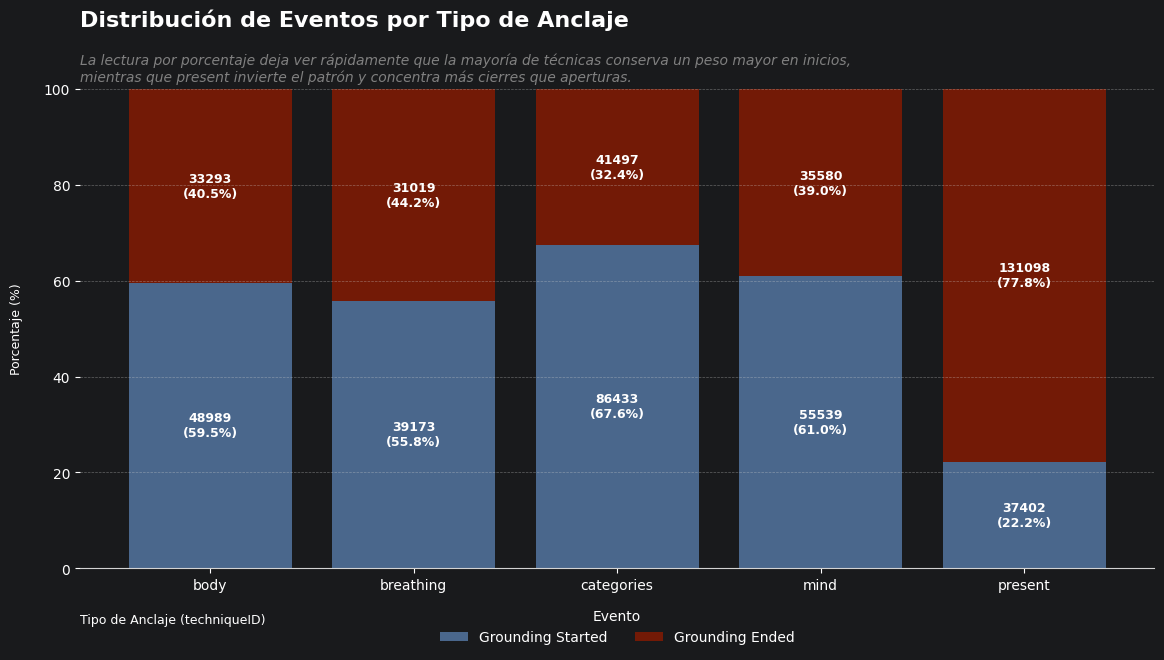

In [72]:
#? 2 Exploracion de la Preparacion de datos para el stacked bar chart
stacked_data = data_as_is.groupby('techniqueID')['event'].value_counts().unstack(fill_value=0)
stacked_data = stacked_data.reindex(columns=['Grounding Started', 'Grounding Ended'])
stacked_pct = stacked_data.div(stacked_data.sum(axis=1), axis=0) * 100

#? 2.1 Visualizacion de distribucion de eventos por tipo de anclaje
fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#4A678C', '#731A06']

bottom = np.zeros(len(stacked_pct))
for i, col in enumerate(stacked_pct.columns):
    bars = ax.bar(stacked_pct.index, stacked_pct[col], bottom=bottom, color=colors[i], label=col)
    for j, bar in enumerate(bars):
        height = bar.get_height()
        if height > 0:
            count = stacked_data.iloc[j][col]
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bottom[j] + height / 2,
                f'{count}\n({height:.1f}%)',
                ha='center',
                va='center',
                fontsize=9,
                color='white',
                fontweight='bold'
            )
    bottom += stacked_pct[col].values

#? 2.2 Titulo y subtitulo storytelling
ax.set_title(
    'Distribución de Eventos por Tipo de Anclaje',
    fontsize=16,
    fontweight='bold',
    loc='left',
    pad=45
)
subtitle = (
    'La lectura por porcentaje deja ver rápidamente que la mayoría de técnicas conserva un peso mayor en inicios,\n'
    'mientras que present invierte el patrón y concentra más cierres que aperturas.'
)
ax.text(
    0.0,
    1.01,
    subtitle,
    transform=ax.transAxes,
    fontsize=10,
    fontstyle='italic',
    color='gray',
    va='bottom',
    ha='left'
)

ax.set_xlabel('Tipo de Anclaje (techniqueID)', fontdict={'fontsize': 9}, labelpad=15, ha='left', x=0)
ax.set_ylabel('Porcentaje (%)', fontdict={'fontsize': 9}, labelpad=15)
ax.set_ylim(0, 100)

#? 2.3 Estilo minimalista
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('lightgray')
ax.grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
ax.legend(title='Evento', loc='upper center', frameon=False, bbox_to_anchor=(0.5, -0.06), ncol=2)

plt.tight_layout(pad=2.0)
plt.show()


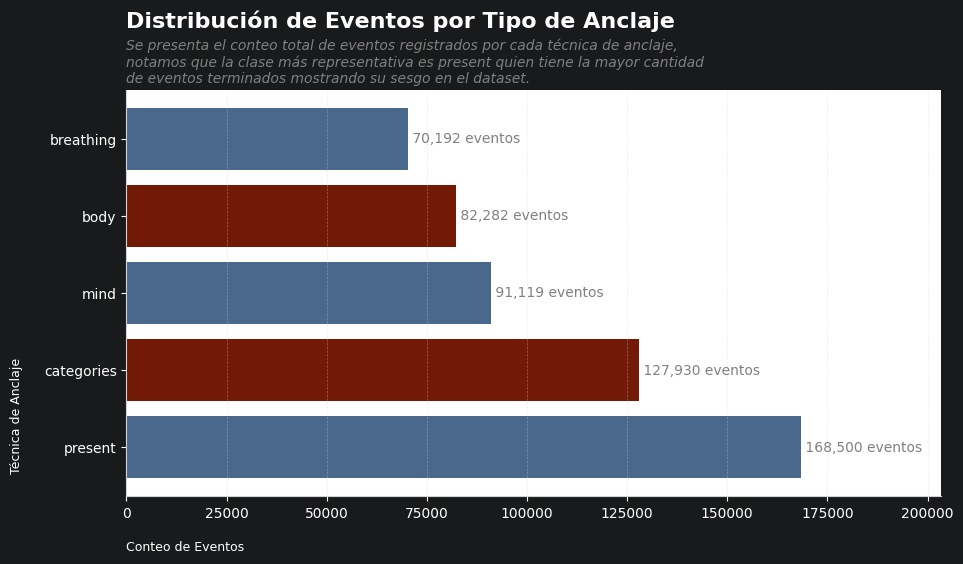

In [73]:
#? 3 Exploracion visual del conteo de registros de cada tecnica de anclaje en general
crear_barchart_storytelling(
    data=result_reset,
    y_axis_data='Técnica',
    x_axis_data='count',
    x_axis_title='Conteo de Eventos',
    y_axis_title='Técnica de Anclaje',
    show_y_axis=True,
    show_x_axis=True,
    bar_label_formatter=lambda v: f' {int(v):,.0f} eventos ',
    fig_size=(10, 6),
    color_palette=colors,
    orientation='horizontal',
    title='Distribución de Eventos por Tipo de Anclaje',
    subtitle='Se presenta el conteo total de eventos registrados por cada técnica de anclaje,\n'
             'notamos que la clase más representativa es present quien tiene la mayor cantidad\nde eventos terminados mostrando su sesgo en el dataset.'
)


In [74]:
#? 4. Exploracion de agregacion diaria de la cantidad de eventos disparados por tipo de anclaje y segmentados por tipo de evento


#? 4.1 Agregacion directa desde el dataframe con columnas OHE
agrupacion_dia_semana_tech = (
    data_cleaned.groupby(['dia_semana_num', 'dia_semana', 'techniqueID'])[['Grounding Started', 'Grounding Ended']]
    .sum()
    .reset_index()
)

events = ['Grounding Started', 'Grounding Ended']

#? 4.2 Definimos la figura donde vamos a graficar nuevamente
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_dia_semana_tech['techniqueID'].unique()
shown_legends = set()

#? 4.3 Iteramos sobre los eventos registrados para determinar el subplot a rellenar
for col_idx, event in enumerate(events, start=1):

    #? 4.3.1 Iteramos sobre las tecnicas para definir las trazas sobre cada lienzo
    for tech in techniques:

        #? 4.3.2 Extraemos la data dpor tecnica para luego filtrar por evento
        tech_data = (agrupacion_dia_semana_tech[agrupacion_dia_semana_tech['techniqueID'] == tech])
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Scatter(
                x=tech_data['dia_semana'],
                y=tech_data[event],
                mode='lines+markers',
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                line=dict(color=TECHNIQUE_COLORS.get(tech)),
                customdata=techniques,
                hovertemplate=f"""
                %{{x}}<br>Eventos:%{{y:,.0f}}<br>Técnica: {tech}<extra></extra>
                """
            ),
            row=1, col=col_idx
        )
#? 4.4 Aplicamos estilo del documento
apply_dashboard_theme(
    fig,
    'Conteo por día de la semana, techniqueID y evento',
    'La lectura por día permite ver qué técnicas sostienen más actividad y dónde aparece el desbalance entre inicio y cierre.',
    height=680,
)
apply_dashboard_axes(fig, x_label='Dia de la Semana', y_label='Conteo',x_axis_label_distance=-0.2,y_axis_label_distance=-0.05)
fig.update_layout(legend_title='Técnica', hovermode='closest')

fig.show()


In [108]:
#? 5. Exploracion visual de la distribucion de eventos por hora del dia (agregada como manana, tarde o noche) y tipo de evento


#? 5.1 Crear columna time_of_day_range basada en una categorizacion horaria: en este caso vamos a aplicar con un .apply en lugar de una seleccion de tipo numpy dado qeu
#? la cantidad de datos que tenemos no es muy grande y no buscamos velocidad de procesamiento
def categorize_time_of_day(hour):
    if 6 <= hour < 12:
        return 'Mañana'
    elif 12 <= hour < 19:
        return 'Tarde'
    else:
        return 'Noche'

#? 5.2 Creamos la columna en base de un apply a la hora
data_cleaned['time_of_day_range'] = data_cleaned['hora'].apply(categorize_time_of_day)
orden_tiempo = ['Mañana', 'Tarde', 'Noche']


#? 5.3 Definimos una agregacion en base al rango de tiempo del dia junto con technique ID, es decir por cada dia, cada una de las tecnicas.
#? Aplicamos reset_index para eliminar el indice compuesto y convertir todo a columnas
agrupacion_tiempo_tech = (
    data_cleaned.groupby(['time_of_day_range', 'techniqueID'])[['Grounding Started', 'Grounding Ended']]
    .sum()
    .reset_index()
)


#? 5.4 Definimos el area de trabajo
events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15
)

techniques = agrupacion_tiempo_tech['techniqueID'].unique()
shown_legends = set()

#? 5.5 Iteramos sobre todos los eventos
for col_idx, event in enumerate(events, start=1):

    #? 5.5.1 Iteramos sobre todas las tecnicas
    for tech in techniques:

        #? 5.5.2 Tomamos la data de cada una de las tecnicas en base al dataset original sin agregaciones multiindicie. Aqui le decimos que el indice sigue siendo el time_of_day_range que
        #? se obtuvo del paso 5.2 y que lo vuelva a ordenar dado que las tecnicas se ordenaron en un inicio por tiempo, pero al filtrar no nos aseguaramos que esten en e orden aropiado
        tech_data = (agrupacion_tiempo_tech[agrupacion_tiempo_tech['techniqueID'] == tech]
                     .set_index('time_of_day_range')
                     .reindex(orden_tiempo)
                     .reset_index())

        #? Mostramos solo la leyenda que no se encuentre ya en la figura
        show_legend = tech not in shown_legends
        shown_legends.add(tech)

        #? 5.5.3 Mostramos una traza por cada combinacion de time of day, evento y por cada categoria
        fig.add_trace(
            go.Scatter(
                x=tech_data['time_of_day_range'],
                y=tech_data[event],
                mode='lines+markers',
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                line=dict(color=TECHNIQUE_COLORS.get(tech)),
                hovertemplate=f"%{{x}}<br>Eventos: %{{y:,.0f}}<br>Técnica: {tech}<extra></extra>"
            ),
            row=1, col=col_idx
        )

#? 5.6 Aplicamos el estilo de la dashboard general
apply_dashboard_theme(
    fig,
    'Conteo por rango horario, techniqueID y evento',
    'Para todos los tipos de anclajes, notamos una alta inclinacion a iniciar y terminar sesiones durante la noche, mostrando una posible razon de la baja tasa de terminacion de <br>sesiones a lo largo de todas las categorias',
    height=680,
)
apply_dashboard_axes(fig, x_label='Rango Horario', y_label='Conteo', x_axis_label_distance=-0.2, y_axis_label_distance=-0.05)
fig.update_layout(legend_title='Técnica', hovermode='closest')
fig.show()


Durante el periodo de análisis, se identifica un patrón claro en la distribución horaria de las sesiones de grounding. Tanto los inicios como las terminaciones muestran una tendencia creciente desde la mañana hacia la noche, lo que evidencia que los usuarios recurren con mayor frecuencia a estas técnicas en horarios nocturnos. Este comportamiento es consistente en todas las técnicas, aunque con intensidades diferentes.

En los eventos de inicio, las técnicas **categories** y **present** destacan con los mayores conteos, consolidándose como las más utilizadas al cierre del día. Sin embargo, en los eventos de finalización, la técnica **present** sobresale aún más, alcanzando un incremento pronunciado en la noche que supera ampliamente al resto. Este contraste sugiere que, aunque varias técnicas se inician con fuerza en horarios nocturnos, es **present** la que logra concretar un mayor número de cierres efectivos o registros erroneos por un error sistematico del dataset.

El hallazgo más relevante es que la concentración de actividad en la noche podría estar vinculada con la baja tasa de finalización observada en general. La acumulación de sesiones iniciadas en ese rango horario, junto con la fatiga o distracciones propias del final del día, puede explicar por qué muchas de ellas no llegan a completarse. Este patrón abre la posibilidad de diseñar intervenciones específicas para mejorar la experiencia nocturna y aumentar la proporción de sesiones que se registran como terminadas.


In [110]:
#? 6. Visualizacion por hora del dia (0-23) segmentada por techniqueID

#? 6.1 Agregacion por hora y techniqueID
agrupacion_hora_tech = (
    data_cleaned.groupby(['hora', 'techniqueID'])[['Grounding Started', 'Grounding Ended']]
    .sum()
    .reset_index()
)

events = ['Grounding Started', 'Grounding Ended']
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=[f'<b>{e}</b>' for e in events],
    horizontal_spacing=0.15,
    vertical_spacing=1
)

techniques = agrupacion_hora_tech['techniqueID'].unique()
shown_legends = set()

for col_idx, event in enumerate(events, start=1):
    for tech in techniques:
        tech_data = (agrupacion_hora_tech[agrupacion_hora_tech['techniqueID'] == tech]
                     .set_index('hora')
                     .reindex(range(24))
                     .reset_index()
                     .fillna(0))
        show_legend = tech not in shown_legends
        shown_legends.add(tech)
        fig.add_trace(
            go.Scatter(
                x=tech_data['hora'],
                y=tech_data[event],
                mode='lines+markers',
                name=tech,
                legendgroup=tech,
                showlegend=show_legend,
                line=dict(color=TECHNIQUE_COLORS.get(tech)),
                hovertemplate=f"Hora: %{{x}}:00<br>Eventos: %{{y:,.0f}}<br>Técnica: {tech}<extra></extra>"
            ),
            row=1, col=col_idx
        )

apply_dashboard_theme(
    fig,
    '','',
    #'Conteo por hora del día, techniqueID y evento',
    #'Durante el periodo de analisis, notamos que cada una de las tecnicas de anclaje tiene un aumento en inicio de sesiones durante las horas de la noche.<br>Aunque hay un pico local '
    #'cerca del medio dia, el repunte para todos los ancljaes sucede entre las 6 PM hasta las 12 PM. En contraste, la mayoria de las categorias muestran una baja cantidad de terminaciones durante<br>los mismos horarios, demostrando que los usuarios tienden a iniciar sesiones a altas horas de la noche que no logran terminar o olvidan de marcar como acabadas',
    height=900,
)
apply_dashboard_axes(fig, x_label='Hora del Día', y_label='Conteo', x_axis_label_distance=-0.2, y_axis_label_distance=-0.05)
fig.update_layout(legend_title='Técnica', hovermode='closest')
fig.update_xaxes(tickmode='linear', tick0=0, dtick=2, zeroline=False)
fig.update_yaxes(zeroline=False)
fig.show()


Durante el periodo de análisis, se observa que los usuarios tienden a iniciar sesiones de grounding con mayor frecuencia en las horas de la noche, mostrando un repunte claro entre las 18:00 y la medianoche. Aunque existe un pico intermedio alrededor del mediodía, la concentración principal de actividad ocurre en la franja nocturna, lo que sugiere que los usuarios recurren a estas técnicas en momentos de cierre de jornada o cuando buscan relajación antes de dormir.

Sin embargo, al analizar las terminaciones de sesiones, se evidencia una discrepancia importante: la mayoría de las técnicas presentan un volumen mucho menor de cierres durante las mismas horas en que se registran más inicios. Esto indica que los usuarios inician sesiones a altas horas de la noche pero no las completan, ya sea por fatiga, distracción o porque olvidan marcar la finalización. La excepción más notable es la técnica **present**, que logra mantener un nivel relativamente alto de cierres en comparación con las demás, consolidándose como la más efectiva en términos de finalización.

Este patrón revela una oportunidad crítica, donde la franja nocturna concentra la mayor demanda de inicio de sesiones, pero también la mayor tasa de abandono. Identificar las causas detrás de esta brecha puede ayudar a diseñar estrategias que fomenten la finalización, como recordatorios, ajustes en la experiencia de usuario o intervenciones específicas que acompañen al usuario en los horarios de mayor vulnerabilidad.

### Porcentaje de Finalizacion de Tecnicas por Usuario


In [77]:
#? 1. Exploracion de tipo funnel cmopuesto de la transicion de estado, de iniciados a finalizados para todas las tecnicas de anclaje

#? 1.1 Agregamos los datos de data cleand en base de las tecnicasm, y usamos en general todos los datos desagregados por fechas para obtener la suma de registros de inicio y fin de sesino
usuarios_por_tecnica = data_cleaned.groupby('techniqueID').agg({
    'Grounding Started': 'sum',
    'Grounding Ended': 'sum'
}).reset_index()


#? 1.2 Definimos una figura en donde vamos a trabajar
fig = go.Figure()

#? 1.3 para cada tecnica registrada creamos una traza en el grafico correspondiente a un Funnel
for tech in usuarios_por_tecnica['techniqueID']:

    #? 1.3.1 Obtenemos los datos de cada tecnica y obtenemos los steps de inicio y final para el funnel
    tech_data = usuarios_por_tecnica[usuarios_por_tecnica['techniqueID'] == tech]
    started = tech_data['Grounding Started'].values[0]
    ended = tech_data['Grounding Ended'].values[0]

    fig.add_trace(go.Funnel(
        name=tech,
        y=['Iniciados', 'Finalizados'],
        x=[started, ended],
        textinfo='value+percent initial',
        marker=dict(color=TECHNIQUE_COLORS.get(tech))
    ))
#? 1.4 Definimos el estilo visual de la dashboard
apply_dashboard_theme(
    fig,
    'Embudo de Finalización por Técnica',
    'En general, el porcentaje de finalizacion de cada una de las tecnicas corresponde a mas del 60%, con el caso excepcional de categories donde el 48% de los usuarios terminan las sesiones sobre todo el dataset<br>Es interesante notar que el efecto de present es opuesto, donde el 351% de usuarios terminan sus sesiones.',
    height=700
)
fig.update_layout(showlegend=True, legend_title='Técnica')
fig.show()


El análisis del embudo de finalización por técnica revela diferencias significativas en la transición entre sesiones iniciadas y finalizadas. Para la mayoría de las técnicas, el porcentaje de cierre se mantiene en niveles aceptables, superiores al 60%, lo que indica que una proporción considerable de usuarios logra completar las actividades que comienzan. Sin embargo, el caso de <code>categories</code> es particularmente crítico, dado que aunque concentra el mayor número de inicios, apenas el 48% de esas sesiones llegan a finalizarse, mostrando una brecha amplia entre intención y ejecución.

Por otro lado, la técnica <code>present</code> rompe el patrón general y se convierte en una excepción notable. Con un volumen inicial relativamente bajo, logra un número de finalizaciones que supera con creces los inicios, alcanzando un 351%. Este comportamiento sugiere que los usuarios que recurren a present no solo completan sus sesiones, sino que además existe un efecto de acumulación o registro adicional que multiplica los cierres en comparación con los inicios.

En conjunto, la transición entre iniciados y finalizados evidencia dos dinámicas opuestas, donde técnicas como <code>categories</code> que generan alta atracción inicial, pero baja retención, y técnicas como <code>present</code> que, aunque menos iniciadas, muestran una capacidad extraordinaria de cierre. Este contraste ofrece pistas valiosas para entender la efectividad de cada técnica y orientar estrategias que reduzcan la fricción en categorías mientras se potencian los factores de éxito presentes en present.


El análisis conjunto de la transición entre sesiones iniciadas y finalizadas, junto con los horarios en que los usuarios seleccionan cada técnica, permite inferir varias preferencias y patrones de comportamiento. En primer lugar, se observa que los usuarios muestran una clara inclinación a iniciar sesiones en horarios nocturnos, especialmente entre las 18:00 y la medianoche. Este repunte sugiere que las técnicas de grounding son utilizadas como recurso de cierre de jornada o como apoyo en momentos de mayor carga emocional al final del día.

Sin embargo, la brecha entre inicios y finalizaciones revela diferencias en la efectividad percibida de cada técnica. **Categories**, por ejemplo, atrae a muchos usuarios al inicio, pero menos de la mitad logra completar la sesión, lo que indica que, aunque es una técnica popular para comenzar, no genera suficiente compromiso para terminar. Esto puede reflejar una preferencia inicial por su simplicidad, pero también una falta de continuidad en la experiencia.

En contraste, **present** muestra un comportamiento opuesto, donde no es la técnica más iniciada, y aun asi logra un número de finalizaciones muy superior, incluso desproporcionado respecto a sus inicios. Esto sugiere que los usuarios que la eligen encuentran en ella un valor añadido que los motiva a cerrar la actividad, consolidando una preferencia por técnicas que ofrecen mayor sensación de logro o efectividad.

En este sentido, podemos inferir que los usuarios prefieren iniciar sesiones en la noche, pero tienden a abandonar aquellas técnicas que no generan suficiente engagement, como categories. Al mismo tiempo, muestran una fuerte preferencia por finalizar sesiones con present, lo que la posiciona como la técnica más confiable para completar el ciclo. Este patrón indica que las preferencias de los usuarios no solo dependen del momento del día, sino también de la percepción de utilidad y satisfacción que cada técnica les ofrece.


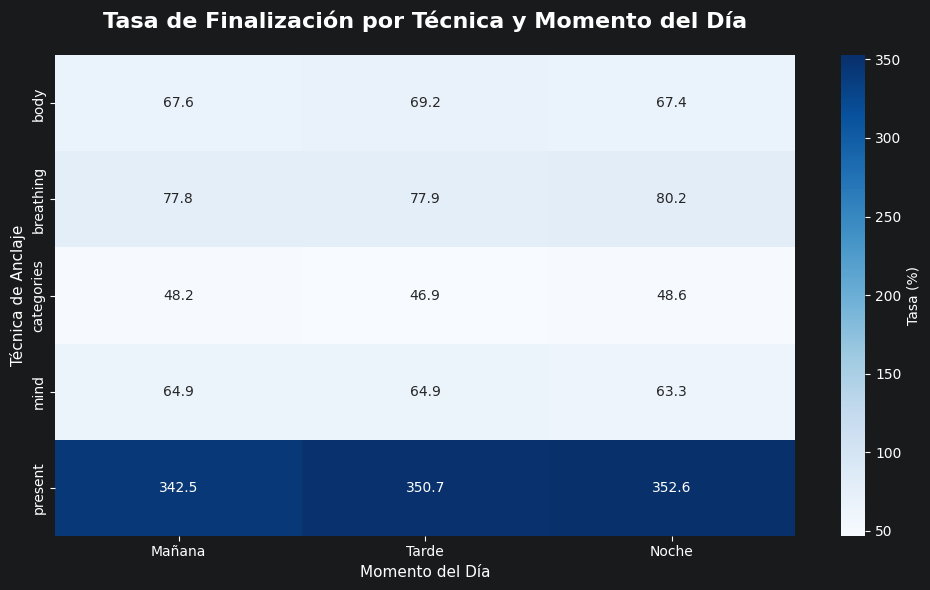

In [78]:
#? 2. Exploracion visual de la tasa de finalizacion por tecnica y momento del dia en base de la cantidad de eventos terminados vs los iniciados por cada tecnica y hora


#? 2.1 Obtenemos los datoe, resulantes de una agrupacion de tecnica -> time of day con la suma de los eventos iniciados y termindaos como los valores
completion_by_time = data_cleaned.groupby(['techniqueID', 'time_of_day_range']).agg({
    'Grounding Started': 'sum',
    'Grounding Ended': 'sum'
}).reset_index()

#? 2.2 Calculamos la tasa de finalizacion como la cantidad de eventos finalizados sobre los eventos iniciados por cada fila del dataset
completion_by_time['tasa_finalizacion'] = (
    completion_by_time['Grounding Ended'] / completion_by_time['Grounding Started'] * 100
)

#? 2.3 Convertirmos a los datos en uan tabla pivote, formato que puede ser usadao directamente en la funcion de sns heatmap
pivot_data = completion_by_time.pivot(index='techniqueID', columns='time_of_day_range', values='tasa_finalizacion')
pivot_data = pivot_data[['Mañana', 'Tarde', 'Noche']] #Seleccionamos las columnas correspondientes al time of date que solicitamos


#? 2.4 Definimos un grafico en donde al pasar la pivot table Seaborn ya sabe que tiene que poer en que eje y como mostrarlo
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': 'Tasa (%)'}, ax=ax)

ax.set_title('Tasa de Finalización por Técnica y Momento del Día', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Momento del Día', fontsize=11)
ax.set_ylabel('Técnica de Anclaje', fontsize=11)

plt.tight_layout()
plt.show()


En base a la distribución de tasas de finalización por técnica y momento del día, se aprecia que los usuarios mantienen comportamientos relativamente estables en técnicas como **body** y **mind**, con porcentajes cercanos al 65% en cualquier franja horaria. Esto sugiere que estas técnicas no dependen tanto del momento del día, sino de la preferencia general del usuario.

En vista de los resultados de **breathing**, se nota una ligera tendencia ascendente hacia la noche, alcanzando un 80%. Esto indica que los usuarios encuentran mayor efectividad o disposición para completar esta técnica en horarios nocturnos, posiblemente asociada a rutinas de relajación antes de dormir.

En contraste, la técnica **categories** muestra un desempeño consistentemente bajo, con tasas alrededor del 48% en todas las franjas. Este comportamiento refleja una preferencia inicial por comenzar la técnica, pero una baja motivación para finalizarla, independientemente del momento del día.

En este caso, la técnica **present** destaca de manera excepcional, con tasas superiores al 340% en todas las franjas horarias, alcanzando su punto más alto en la tarde y la noche. Este resultado sugiere que los usuarios no solo completan las sesiones iniciadas, sino que además existe un efecto acumulativo que multiplica los cierres, consolidando a present como la técnica más valorada y efectiva en términos de finalización, que como se ha discutido puede deberse a un problema de registro en la aplicación.

En conjunto, los datos permiten inferir que los usuarios prefieren técnicas que les aseguren un cierre exitoso, como <code>present</code> y <code>breathing</code>, mientras que categorías como <code>categories</code> requieren ajustes para mejorar la experiencia y aumentar la tasa de finalización.


In [79]:
#? 3. Exploracion visual del porcentjae de finalizacion vs no finalizado

#? 3.1 Obtenemos los datos en base de una agrupacion por cada tecnica, definiendo la suma de vetos iniciados y terminados de tood el dataset como la fuente
usuarios_por_tecnica = data_cleaned.groupby('techniqueID').agg({
    'Grounding Started': 'sum',
    'Grounding Ended': 'sum'
}).reset_index()

#? 3.2 tomamos la cantidad de tecnicas existentes para definir la cantidad de subplots paralelos a definir
techniques = usuarios_por_tecnica['techniqueID'].unique()
n_techs = len(techniques)

#? 3.3 Creamos los subplots
fig = make_subplots(
    rows=1, cols=n_techs,
    specs=[[{'type': 'domain'}] * n_techs],
    subplot_titles=[f'<b>{t}</b>' for t in techniques]
)

#? 3.4 Por cada tecnica obtenemos sus datos, y los datos de eventos de terinacion y eventos de inicio para calcular los eventos terminados y su diferencia
for i, tech in enumerate(techniques, start=1):
    tech_data = usuarios_por_tecnica[usuarios_por_tecnica['techniqueID'] == tech]
    ended = tech_data['Grounding Ended'].values[0]
    not_ended = tech_data['Grounding Started'].values[0] - ended

    #? 3.4.1 Anadimos un grafico de pastel con los datos necesarios
    fig.add_trace(go.Pie(
        labels=['Finalizados', 'No Finalizados'],
        values=[ended, not_ended],
        hole=0.60,
        marker_colors=[COLOR_GREY,"#731A06"], #Definimos storytelling mediante el color marron como el resalte para sesiones no finalizada, y el gris paralas finalizadas
        textinfo='percent',
        showlegend=(i == 1)
    ), row=1, col=i)

#? 3.5 Aplicamos el estilo de la dashboard
apply_dashboard_theme(
    fig,
    'Proporción de Finalización por Técnica',
    'Notams una proporcion de eventos no finalizados relativamente baja para la mayoria de los tipos de anclaje, donde el porcentaje de sesiones no finalizadas es menor o igual al 40%.<br>Para'
    'clases especificas como <b>categories o present</b>, la inversion en casos es importante, <b>categories</b> cuenta con un 52% de sesiones no finalziadas, mientras que <b>present</b> muestra un 351% de eventos finalizados,<br>liderado por el hecho de que tenga cuatro veces mas registros de finalizacion que inicio',
    height=500
)
fig.show()


In [80]:
#? 4. Exploracion visual de la transferencia de usuarios desde el estado de iniciado hasta eventos finalizados y no finalizados, teniendo en cuenta la cantidad inicial de eventos iniciaodos y el conteo de eventos finalizados para calcular los eventos no finalizados y mostrarlos en el grafico



#? 4.1 Calcular usuarios que iniciaron y finalizaron por técnica
usuarios_por_tecnica = data_cleaned.groupby('techniqueID').agg({
    'Grounding Started': 'sum',
    'Grounding Ended': 'sum'
}).reset_index()


#? 4.2 Calculamos los usuarios no finalizados en base del conteo de eventos iniciados menos los terminados, generalmente es una resta positiva donde los eventos terminados son mayores a los iniciados
usuarios_por_tecnica['No Finalizados'] = (
    usuarios_por_tecnica['Grounding Started'] - usuarios_por_tecnica['Grounding Ended']
)

#? 4.3 Preparar nodos: técnicas + estados (Finalizados, No Finalizados)
techniques = usuarios_por_tecnica['techniqueID'].tolist()
estados = ['Finalizados', 'No Finalizados']
all_nodes = techniques + estados

#? 4.4 Crear mapeo de índices
node_indices = {str(node): idx for idx, node in enumerate(all_nodes)}

#? 4.5 Creamos el flujo de transicion de terminacion y no finalizados basados en todas las filas del dataset de usuarios por tecnica, es decir
#? por cada una de las tecnicas. Aqui llenamos sources como el indice de salida, targets como el indice de llegada, values como el valor final, y el color requerido
#? Esta seccion genera dos flujos diferentes dependiendo de si existe un valor para cada uno de los grupos, la revision si No Finalizados es mayor que cero evita una linea negativa
#? de la clase de present que tiene mas cancelaciones que inicios.
sources = []
targets = []
values = []
colors = []

for _, row in usuarios_por_tecnica.iterrows():
    #? 4.5.1 Obtienes la technique para su identificacion
    tech = row['techniqueID']
    tech_idx = node_indices[tech]

    #? 4.5.2 Flujo a Finalizados
    if row['Grounding Ended'] > 0:
        sources.append(tech_idx)
        targets.append(node_indices['Finalizados'])
        values.append(row['Grounding Ended'])
        colors.append('rgba(74, 144, 226, 0.4)')  # Azul transparente

    #? 4.5.3 Flujo a No Finalizados
    if row['No Finalizados'] > 0:
        sources.append(tech_idx)
        targets.append(node_indices['No Finalizados'])
        values.append(row['No Finalizados'])
        colors.append('rgba(232, 232, 232, 0.7)')  # Gris transparente

#? 4.5.4 Colores de nodos
node_colors = [TECHNIQUE_COLORS.get(str(tech), '#CCCCCC') for tech in techniques] + ['#4A90E2', '#AEAEAE']


#? 4.6 Definimos la figura de forma de sankey, en donde le mandamos en forma de un diccionario la informacion de las listas de sources, targets, value and colors
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=15,
        thickness=20,
        line=dict(color='white', width=0.5),
        #? Este arreglo tiene todas las labels, incluida la de los estados finales y las clases
        label=all_nodes,
        #? Esta tiene todos los colores de los nodos y los estados finales
        color=node_colors,
        customdata=[f'{node}' for node in all_nodes],
        hovertemplate='%{customdata}<br>Total: %{value:,.0f}<extra></extra>'
    ),
    #? Este diccionario le dice como tiene que unir los datos en base a los indices idxs
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color=colors,
        hovertemplate='%{source.label} → %{target.label}<br>Eventos: %{value:,.0f}<extra></extra>'
    )
)])

#? 4.7 Aplicamos estado general de graficos del dataset
apply_dashboard_theme(
    fig,
    'Flujo de Finalización por Técnica de Anclaje',
    'Durante el periodo se puede evidenciar que en general, la cantidad de usuarios que pierde interes con cerrar las sesinoes iniciadas es bajo para la mayoría de categorías fáciles<br>'
    'como <b>body, mind o breathing</b>, mientras que para categorias como <b>categories</b> muestran un resultado en donde casi la mitad de usuarios no cierra sus sesiones, mostrando un<br>'
    'grave problema de churning para esta tecnica de anclaje',
    height=700
)

fig.update_layout(
    font=dict(size=11),
    margin=dict(l=20, r=20, t=120, b=40)
)

fig.show()


En base de la visualización del flujo de finalización por técnica de anclaje, se puede deducir que los usuarios muestran distintos niveles de compromiso según la técnica seleccionada. Las técnicas como **body**, **mind** y **breathing** mantienen un flujo mayor hacia la categoría de finalizados, lo que refleja una preferencia por actividades que resultan más fáciles de completar o que generan una experiencia más estable. Esto sugiere que los usuarios que optan por estas técnicas buscan consistencia y logran cerrar la mayoría de sus sesiones.

En contraste, la técnica **categories** presenta un flujo considerable hacia la opción de no finalizados, lo que indica una tendencia a abandonar la actividad antes de concluirla. Este comportamiento revela que, aunque la técnica atrae a muchos usuarios al inicio, no logra sostener su interés hasta el final. En este caso, la preferencia parece estar más asociada a la curiosidad inicial que a la satisfacción de completar la sesión.

En vista de la técnica **present**, el flujo se inclina de manera abrumadora hacia los finalizados, lo que confirma que los usuarios que la seleccionan encuentran un valor añadido que los motiva a cerrar sus sesiones. Este patrón refuerza la idea de que present es percibida como una técnica más efectiva y gratificante, consolidando una preferencia clara por su uso en comparación con las demás. Por otro lado, si seguimos la línea de pensamiento de que los registros pueden ser errores sistemáticos de un segmento de la aplicación en donde se registra incorrectamente los resultados de una terminación de sesión, la historia ahora muestra un resultado inflado dado este error de registro.

En conjunto, el análisis del flujo permite inferir que las preferencias de los usuarios no solo se reflejan en la elección inicial de la técnica, sino también en su capacidad de mantener el compromiso hasta el final. Las técnicas con mayor tasa de finalización responden a una búsqueda de efectividad y satisfacción, mientras que aquellas con altos niveles de abandono evidencian fricción en la experiencia que limita su impacto.


### Porcentaje de Tecnicas usadas en conjunto o cercanas entre si

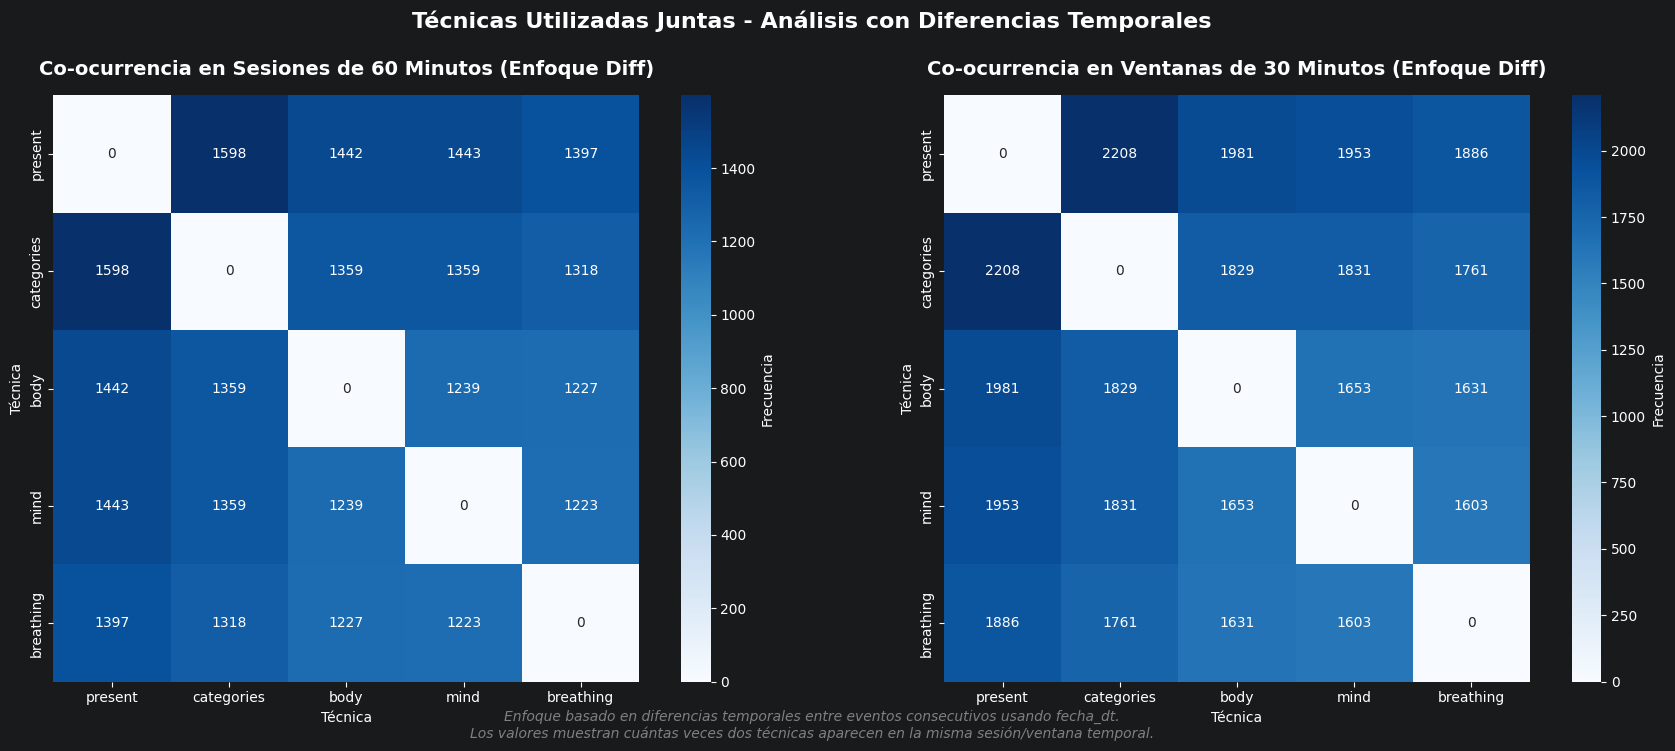


TOP 10 COMBINACIONES EN SESIONES DE 60 MINUTOS (ENFOQUE DIFF)
    Técnica 1   Técnica 2  Frecuencia
0     present  categories        1598
2     present        mind        1443
1     present        body        1442
3     present   breathing        1397
4  categories        body        1359
5  categories        mind        1359
6  categories   breathing        1318
7        body        mind        1239
8        body   breathing        1227
9        mind   breathing        1223

TOP 10 COMBINACIONES EN VENTANAS DE 30 MINUTOS (ENFOQUE DIFF)
    Técnica 1   Técnica 2  Frecuencia
0     present  categories        2208
1     present        body        1981
2     present        mind        1953
3     present   breathing        1886
5  categories        mind        1831
4  categories        body        1829
6  categories   breathing        1761
7        body        mind        1653
8        body   breathing        1631
9        mind   breathing        1603


In [81]:
#? 1. Exploracion analitica de la co-occurencia de tipos de anclajes basada en las hipotesis definidas en el analisis de la pregunta
#? Un periodo de tiempo de 60 minutos consecutivos se considera una sesion y 30 minutos una relacion de momentos cercanos


#? 1.1. Calcular diferencia de tiempo entre eventos consecutivos. La funcion de diff calcula la diferencia numerica o el time delta en horas minutos o segundos
#? de la fila de arriba comparada con la de abajo, haciendo time abajo - time arriba desde la segunda celda para calcular las diferencias temporales entre registros. En nuestro caso
#? la funcion calcula la diferencia entre series de tiempo consecutivas basada en nuestra columna date and time
data_cleaned['time_diff'] = data_cleaned['date_dt'].diff()

#? 1.2 Definimos dos timedeltas, especificamente las diferencias de tiempo en minutos que toleramos para poder comparar los intervalos de tiempo calculados por .diff
#? con los thresholds definidos de 60 y 30 minutos. .diff() retorna timedeltas que representan las diferencias calculadas por lo que al definir estos timedeltas nos permite
#? realizar comparaciones directas
gap_threshold_session = timedelta(minutes=60)  # Sesión: eventos separados por <= 60 minutos
gap_threshold_close = timedelta(minutes=30)    # Momentos cercanos: eventos separados por <= 30 minutos

#? 1.3. Identificar inicio de nuevas sesiones (ventanas de 60 minutos)
#? Si la diferencia de tiempo es mayor a 60 minutos O es el primer evento (NaN), inicia nueva sesión
data_cleaned['new_session_60min'] = (data_cleaned['time_diff'] > gap_threshold_session) | (data_cleaned['time_diff'].isna())

#? 1.4. Asignar ID único a cada sesión mediante suma acumulativa de los marcadores de nueva sesión
#? La funcion cumsum() suma acumulativamente los valores True (1) y False (0), creando un contador que incrementa cada vez que se detecta una nueva sesión
data_cleaned['session_id_60min'] = data_cleaned['new_session_60min'].cumsum()

#? 1.5. Identificar inicio de nuevas ventanas de momentos cercanos (30 minutos)
#? Aplicamos la misma lógica que en 1.3 pero con el threshold de 30 minutos para capturar relaciones temporales más cercanas entre eventos
data_cleaned['new_session_30min'] = (data_cleaned['time_diff'] > gap_threshold_close) | (data_cleaned['time_diff'].isna())

#? 1.6. Asignar ID único a cada ventana de 30 minutos
#? Similar a 1.4, creamos identificadores únicos para cada ventana temporal de 30 minutos mediante suma acumulativa
data_cleaned['session_id_30min'] = data_cleaned['new_session_30min'].cumsum()


#? 1.7. Agrupar técnicas por sesión de 60 minutos
#? Agrupamos todos los eventos que pertenecen a la misma sesión (mismo session_id_60min) y recolectamos todas las técnicas utilizadas en esa sesión en una lista
session_cooccurrence_diff = (
    data_cleaned.groupby('session_id_60min')['techniqueID']
    .apply(list)
    .reset_index()
)

#? 1.8. Calcular estadísticas de sesiones de 60 minutos
#? Calculamos el número total de eventos en cada sesión contando la longitud de la lista de técnicas
session_cooccurrence_diff['num_events'] = session_cooccurrence_diff['techniqueID'].apply(len)

#? 1.9. Calcular el número de técnicas únicas por sesión
#? Convertimos la lista de técnicas a un set para eliminar duplicados y luego contamos cuántas técnicas diferentes se usaron en cada sesión
session_cooccurrence_diff['unique_techniques'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))

#? 1.10. Crear lista de técnicas únicas por sesión
#? Guardamos la lista de técnicas únicas (sin duplicados) para cada sesión, lo cual será útil para el análisis de co-ocurrencia posterior
session_cooccurrence_diff['technique_list'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 1.11. Filtrar sesiones con múltiples técnicas
#? Nos enfocamos solo en sesiones donde se usaron 2 o más técnicas diferentes, ya que estas son las que nos interesan para analizar co-ocurrencia
session_cooccurrence_diff_multi = session_cooccurrence_diff[session_cooccurrence_diff['unique_techniques'] > 1].copy()


#? 1.12. Agrupar técnicas por ventana de 30 minutos
#? Aplicamos el mismo proceso de agrupación que en 1.7 pero usando las ventanas de 30 minutos para capturar relaciones temporales más cercanas
close_moment_cooccurrence_diff = (
    data_cleaned.groupby('session_id_30min')['techniqueID']
    .apply(list)
    .reset_index()
)

#? 1.13. Calcular estadísticas de ventanas de 30 minutos - Número de eventos
#? Contamos cuántos eventos ocurrieron en cada ventana de 30 minutos
close_moment_cooccurrence_diff['num_events'] = close_moment_cooccurrence_diff['techniqueID'].apply(len)

#? 1.14. Calcular estadísticas de ventanas de 30 minutos - Técnicas únicas
#? Determinamos cuántas técnicas diferentes se utilizaron en cada ventana de 30 minutos
close_moment_cooccurrence_diff['unique_techniques'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))

#? 1.15. Crear lista de técnicas únicas por ventana de 30 minutos
#? Almacenamos las técnicas únicas para cada ventana temporal de 30 minutos
close_moment_cooccurrence_diff['technique_list'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 1.16. Filtrar ventanas de 30 minutos con múltiples técnicas
#? Seleccionamos solo las ventanas donde se usaron 2 o más técnicas diferentes para el análisis de co-ocurrencia
close_moment_cooccurrence_diff_multi = close_moment_cooccurrence_diff[close_moment_cooccurrence_diff['unique_techniques'] > 1].copy()


#? 1.17. Crear matriz de co-ocurrencia para sesiones de 60 minutos
#? Inicializamos una matriz cuadrada con ceros donde las filas y columnas representan todas las técnicas disponibles
techniques = data_cleaned['techniqueID'].unique()
co_occurrence_60min_diff = pd.DataFrame(0, index=techniques, columns=techniques)

#? 1.18. Poblar matriz de co-ocurrencia de 60 minutos
#? Iteramos sobre cada sesión que tiene múltiples técnicas
for tech_list in session_cooccurrence_diff_multi['techniqueID']:
    unique_techs = list(set(tech_list))  # Eliminar duplicados dentro de la misma sesión para evitar contar la misma técnica múltiples veces
    if len(unique_techs) > 1:
        #? Para cada par de técnicas únicas en la sesión, incrementamos el contador en la matriz
        #? Usamos combinations para generar todos los pares posibles sin repetición (A,B) pero no (B,A) como par separado
        for tech1, tech2 in combinations(unique_techs, 2):
            co_occurrence_60min_diff.loc[tech1, tech2] += 1  # Incrementar celda superior
            co_occurrence_60min_diff.loc[tech2, tech1] += 1  # Incrementar celda inferior para mantener simetría

#? 1.19. Crear matriz de co-ocurrencia para ventanas de 30 minutos
#? Inicializamos una segunda matriz para analizar co-ocurrencia en ventanas temporales más cortas
co_occurrence_30min_diff = pd.DataFrame(0, index=techniques, columns=techniques)

#? 1.20. Poblar matriz de co-ocurrencia de 30 minutos
#? Aplicamos la misma lógica que en 1.18 pero para las ventanas de 30 minutos, capturando relaciones temporales más inmediatas
for tech_list in close_moment_cooccurrence_diff_multi['techniqueID']:
    unique_techs = list(set(tech_list))  # Eliminar duplicados
    if len(unique_techs) > 1:
        #? Incrementar contador para cada par de técnicas que co-ocurren en la misma ventana de 30 minutos
        for tech1, tech2 in combinations(unique_techs, 2):
            co_occurrence_30min_diff.loc[tech1, tech2] += 1
            co_occurrence_30min_diff.loc[tech2, tech1] += 1

#? 1.21. Visualización: Heatmaps comparativos de co-ocurrencia con enfoque diff
#? Creamos una figura con dos subplots lado a lado para comparar visualmente los patrones de co-ocurrencia en ambas ventanas temporales
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#? 1.22. Heatmap para sesiones de 60 minutos
#? Visualizamos la matriz de co-ocurrencia de 60 minutos usando un mapa de calor donde colores más oscuros indican mayor frecuencia de co-ocurrencia
sns.heatmap(
    co_occurrence_60min_diff,
    annot=True,  # Mostrar valores numéricos en cada celda
    fmt='d',     # Formato entero para los valores
    cmap='Blues',  # Paleta de colores azules
    cbar_kws={'label': 'Frecuencia'},  # Etiqueta para la barra de color
    ax=axes[0],
    square=True  # Mantener celdas cuadradas para mejor visualización
)
axes[0].set_title('Co-ocurrencia en Sesiones de 60 Minutos (Enfoque Diff)',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Técnica', fontsize=10)
axes[0].set_ylabel('Técnica', fontsize=10)

#? 1.23. Heatmap para ventanas de 30 minutos
#? Creamos el segundo heatmap para visualizar co-ocurrencias en ventanas temporales más cortas
sns.heatmap(
    co_occurrence_30min_diff,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar_kws={'label': 'Frecuencia'},
    ax=axes[1],
    square=True
)
axes[1].set_title('Co-ocurrencia en Ventanas de 30 Minutos (Enfoque Diff)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Técnica', fontsize=10)
axes[1].set_ylabel('Técnica', fontsize=10)

#? 1.24. Añadir título general y subtítulo explicativo
#? Agregamos contexto sobre la metodología y la interpretación de los resultados
fig.suptitle(
    'Técnicas Utilizadas Juntas - Análisis con Diferencias Temporales',
    fontsize=16, fontweight='bold', y=1.02
)
fig.text(
    0.5, -0.02,
    'Enfoque basado en diferencias temporales entre eventos consecutivos usando fecha_dt.\n'
    'Los valores muestran cuántas veces dos técnicas aparecen en la misma sesión/ventana temporal.',
    ha='center', fontsize=10, fontstyle='italic', color='gray'
)

plt.tight_layout()
plt.show()

#? 1.25. Análisis de las combinaciones más frecuentes (60 minutos)
#? Extraemos y ordenamos los pares de técnicas por frecuencia de co-ocurrencia para identificar las combinaciones más comunes
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES EN SESIONES DE 60 MINUTOS (ENFOQUE DIFF)")
print("=" * 70)
pairs_60min_diff = []

#? 1.26. Iterar sobre la matriz triangular superior para evitar duplicados
#? Solo consideramos i < j para evitar contar el mismo par dos veces (ej: A-B y B-A)
for i, tech1 in enumerate(techniques):
    for j, tech2 in enumerate(techniques):
        if i < j and co_occurrence_60min_diff.loc[tech1, tech2] > 0:
            pairs_60min_diff.append({
                'Técnica 1': tech1,
                'Técnica 2': tech2,
                'Frecuencia': co_occurrence_60min_diff.loc[tech1, tech2]
            })

#? 1.27. Convertir a DataFrame y ordenar por frecuencia descendente
#? Organizamos los pares de técnicas de mayor a menor frecuencia para identificar las combinaciones más relevantes
pairs_60min_diff_df = pd.DataFrame(pairs_60min_diff).sort_values('Frecuencia', ascending=False)
print(pairs_60min_diff_df.head(10))

#? 1.28. Análisis de las combinaciones más frecuentes (30 minutos)
#? Repetimos el análisis para las ventanas de 30 minutos para comparar patrones de co-ocurrencia en diferentes escalas temporales
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES EN VENTANAS DE 30 MINUTOS (ENFOQUE DIFF)")
print("=" * 70)
pairs_30min_diff = []

#? 1.29. Extraer pares de técnicas de la matriz de 30 minutos
#? Aplicamos la misma lógica de extracción que en 1.26 pero para la ventana temporal más corta
for i, tech1 in enumerate(techniques):
    for j, tech2 in enumerate(techniques):
        if i < j and co_occurrence_30min_diff.loc[tech1, tech2] > 0:
            pairs_30min_diff.append({
                'Técnica 1': tech1,
                'Técnica 2': tech2,
                'Frecuencia': co_occurrence_30min_diff.loc[tech1, tech2]
            })

#? 1.30. Ordenar y mostrar las combinaciones más frecuentes de 30 minutos
#? Presentamos las 10 combinaciones más comunes en ventanas de 30 minutos para identificar relaciones temporales inmediatas entre técnicas
pairs_30min_diff_df = pd.DataFrame(pairs_30min_diff).sort_values('Frecuencia', ascending=False)
print(pairs_30min_diff_df.head(10))


DISTRIBUCIÓN DE SESIONES DE 60 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)
1 técnica(s): 122 sesiones (4.75%)
2 técnica(s): 600 sesiones (23.36%)
3 técnica(s): 535 sesiones (20.83%)
4 técnica(s): 430 sesiones (16.74%)
5 técnica(s): 882 sesiones (34.33%)

DISTRIBUCIÓN DE VENTANAS DE 30 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)
1 técnica(s): 188 ventanas (5.19%)
2 técnica(s): 884 ventanas (24.42%)
3 técnica(s): 792 ventanas (21.88%)
4 técnica(s): 621 ventanas (17.15%)
5 técnica(s): 1135 ventanas (31.35%)


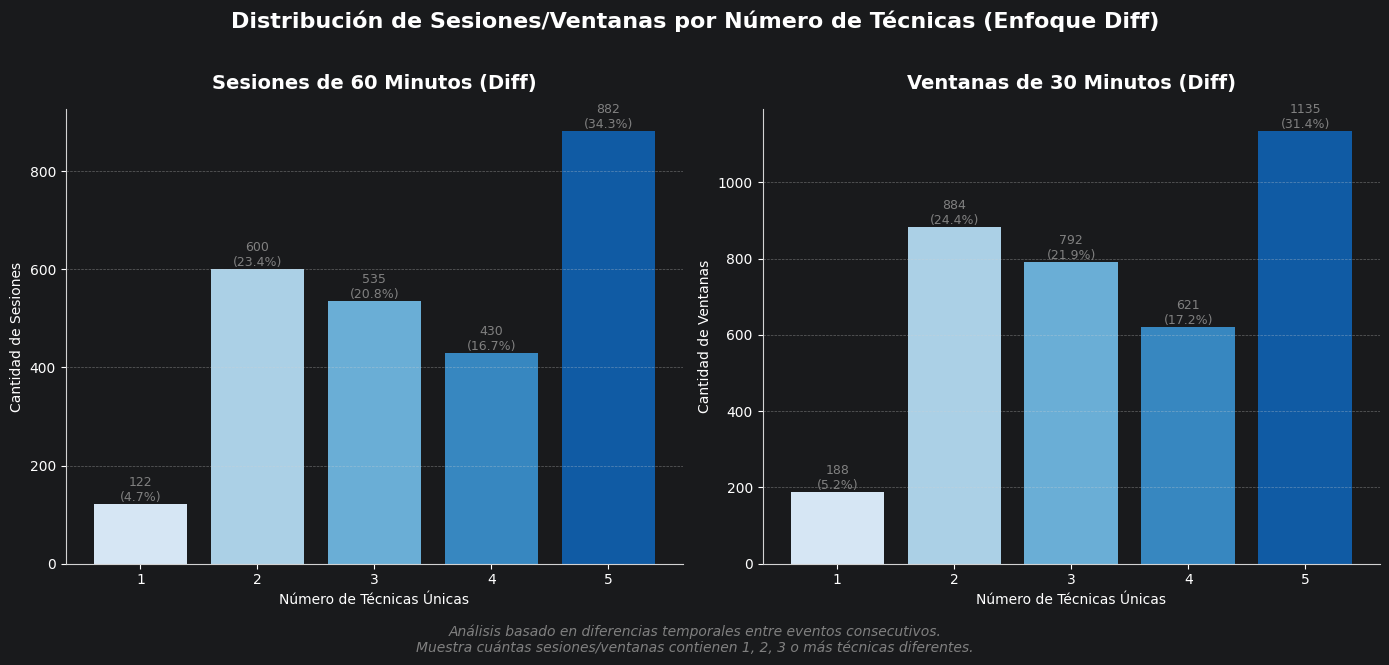


TOP 10 COMBINACIONES ESPECÍFICAS - SESIONES DE 60 MINUTOS (DIFF)
                                       Combinación  Frecuencia
0   body + breathing + categories + mind + present         882
2               body + categories + mind + present         127
6                             categories + present         126
22         body + breathing + categories + present         102
17                     categories + mind + present          97
18         breathing + categories + mind + present          95
12                     body + categories + present          87
5                                   body + present          84
11                breathing + categories + present          82
20                                  mind + present          77
                                       Combinación  Frecuencia
0   body + breathing + categories + mind + present        1135
1                             categories + present         201
3               body + categories + mind + present  

In [82]:
#? 2. Análisis de sesiones por cantidad de técnicas utilizadas (Enfoque Diff)

from itertools import combinations

#? 2.1. Calcular técnicas únicas por sesión de 60 minutos
#? Aplicamos una función lambda que convierte la lista de técnicas a un set (eliminando duplicados) y cuenta cuántas técnicas únicas hay en cada sesión
session_cooccurrence_diff['unique_techniques'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))

#? 2.2. Crear lista de técnicas únicas por sesión de 60 minutos
#? Guardamos las técnicas únicas como lista para facilitar análisis posteriores de combinaciones específicas
session_cooccurrence_diff['technique_list'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 2.3. Contar sesiones por número de técnicas únicas (60 minutos)
#? Usamos value_counts() para obtener la frecuencia de cada cantidad de técnicas y sort_index() para ordenar de menor a mayor número de técnicas
session_technique_counts_diff = session_cooccurrence_diff['unique_techniques'].value_counts().sort_index()

#? 2.4. Mostrar distribución de sesiones de 60 minutos
#? Imprimimos un resumen que muestra cuántas sesiones tienen 1, 2, 3, etc. técnicas, junto con el porcentaje que representa del total
print("=" * 70)
print("DISTRIBUCIÓN DE SESIONES DE 60 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)")
print("=" * 70)
for num_techs, count in session_technique_counts_diff.items():
    pct = count / len(session_cooccurrence_diff) * 100
    print(f"{num_techs} técnica(s): {count} sesiones ({pct:.2f}%)")

#? 2.5. Calcular técnicas únicas por ventana de 30 minutos
#? Repetimos el proceso de 2.1 pero para las ventanas temporales más cortas de 30 minutos
close_moment_cooccurrence_diff['unique_techniques'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))

#? 2.6. Crear lista de técnicas únicas por ventana de 30 minutos
#? Almacenamos las técnicas únicas de cada ventana de 30 minutos para análisis detallado de combinaciones
close_moment_cooccurrence_diff['technique_list'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 2.7. Contar ventanas por número de técnicas únicas (30 minutos)
#? Generamos la distribución de frecuencias para las ventanas de 30 minutos, similar a 2.3
close_moment_technique_counts_diff = close_moment_cooccurrence_diff['unique_techniques'].value_counts().sort_index()

#? 2.8. Mostrar distribución de ventanas de 30 minutos
#? Presentamos el resumen de cuántas ventanas contienen cada cantidad de técnicas únicas
print("\n" + "=" * 70)
print("DISTRIBUCIÓN DE VENTANAS DE 30 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)")
print("=" * 70)
for num_techs, count in close_moment_technique_counts_diff.items():
    pct = count / len(close_moment_cooccurrence_diff) * 100
    print(f"{num_techs} técnica(s): {count} ventanas ({pct:.2f}%)")

#? 2.9. Filtrar sesiones/ventanas con 2 o más técnicas
#? Seleccionamos solo las sesiones y ventanas que tienen múltiples técnicas, ya que estas son las relevantes para analizar co-ocurrencia
session_multi_tech_diff = session_cooccurrence_diff[session_cooccurrence_diff['unique_techniques'] >= 2]
close_moment_multi_tech_diff = close_moment_cooccurrence_diff[close_moment_cooccurrence_diff['unique_techniques'] >= 2]


#? 2.11. Visualización: Gráfico de barras comparativo (Enfoque Diff)
#? Creamos una figura con dos subplots para comparar visualmente las distribuciones de ambas ventanas temporales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#? 2.12. Generar paleta de colores para gráfico de 60 minutos
#? Usamos la función generate_blue_palette para crear una gradiente de azules según el número de categorías
colors_60min = generate_blue_palette(len(session_technique_counts_diff))

#? 2.13. Crear gráfico de barras para sesiones de 60 minutos
#? Visualizamos la distribución de sesiones por número de técnicas usando barras verticales
axes[0].bar(session_technique_counts_diff.index, session_technique_counts_diff.values, color=colors_60min)
axes[0].set_title('Sesiones de 60 Minutos (Diff)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Número de Técnicas Únicas', fontsize=10)
axes[0].set_ylabel('Cantidad de Sesiones', fontsize=10)

#? 2.14. Configurar estilo del gráfico de 60 minutos
#? Añadimos grid horizontal y configuramos los spines (bordes) para un estilo minimalista
axes[0].grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_color('lightgray')
axes[0].spines['bottom'].set_color('lightgray')

#? 2.15. Añadir etiquetas con conteo y porcentaje (60 minutos)
#? Colocamos texto sobre cada barra mostrando el conteo absoluto y el porcentaje del total
for i, (num, count) in enumerate(session_technique_counts_diff.items()):
    axes[0].text(num, count, f'{count}\n({count/len(session_cooccurrence_diff)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, color='gray')

#? 2.16. Generar paleta de colores para gráfico de 30 minutos
#? Creamos una nueva paleta de colores para el segundo gráfico
colors_30min = generate_blue_palette(len(close_moment_technique_counts_diff))

#? 2.17. Crear gráfico de barras para ventanas de 30 minutos
#? Visualizamos la distribución de ventanas de 30 minutos por número de técnicas
axes[1].bar(close_moment_technique_counts_diff.index, close_moment_technique_counts_diff.values, color=colors_30min)
axes[1].set_title('Ventanas de 30 Minutos (Diff)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Número de Técnicas Únicas', fontsize=10)
axes[1].set_ylabel('Cantidad de Ventanas', fontsize=10)

#? 2.18. Configurar estilo del gráfico de 30 minutos
#? Aplicamos el mismo estilo minimalista que en el gráfico de 60 minutos para mantener consistencia visual
axes[1].grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('lightgray')
axes[1].spines['bottom'].set_color('lightgray')

#? 2.19. Añadir etiquetas con conteo y porcentaje (30 minutos)
#? Mostramos los valores numéricos y porcentajes sobre cada barra del segundo gráfico
for i, (num, count) in enumerate(close_moment_technique_counts_diff.items()):
    axes[1].text(num, count, f'{count}\n({count/len(close_moment_cooccurrence_diff)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, color='gray')

#? 2.20. Añadir título general del gráfico completo
#? Colocamos un título superior que describe ambos subplots
fig.suptitle(
    'Distribución de Sesiones/Ventanas por Número de Técnicas ',
    fontsize=16, fontweight='bold', y=1.02
)

#? 2.21. Añadir subtítulo explicativo
#? Incluimos una descripción metodológica y de interpretación en la parte inferior
fig.text(
    0.5, -0.05,
    'Análisis basado en diferencias temporales entre eventos consecutivos.\n'
    'Muestra cuántas sesiones/ventanas contienen 1, 2, 3 o más técnicas diferentes.',
    ha='center', fontsize=10, fontstyle='italic', color='gray'
)

plt.tight_layout()
plt.show()

#? 2.23. Iterar sobre sesiones con múltiples técnicas (60 minutos)
#? Procesamos cada sesión que tiene 2 o más técnicas para contar las combinaciones específicas
#? 7. Análisis detallado: Combinaciones específicas más frecuentes (60 minutos)
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES ESPECÍFICAS - SESIONES DE 60 MINUTOS (DIFF)")
print("=" * 70)
combination_counts_60min = {}

for tech_list in session_multi_tech_diff['technique_list']:
    if len(tech_list) >= 2:
        #? 2.24. Crear tupla ordenada para evitar duplicados (A,B) vs (B,A)
        #? Ordenamos alfabéticamente las técnicas para que (A,B) y (B,A) se cuenten como la misma combinación
        combo = tuple(sorted(tech_list))
        combination_counts_60min[combo] = combination_counts_60min.get(combo, 0) + 1

#? 2.25. Convertir a DataFrame y ordenar por frecuencia descendente (60 minutos)
#? Transformamos el diccionario de combinaciones en un DataFrame para facilitar la visualización y ordenamos de mayor a menor frecuencia
combo_60min_df = pd.DataFrame([
    {'Combinación': ' + '.join(combo), 'Frecuencia': count}
    for combo, count in combination_counts_60min.items()
]).sort_values('Frecuencia', ascending=False)

#? 2.26. Mostrar las 10 combinaciones más frecuentes (60 minutos)
print(combo_60min_df.head(10))
combination_counts_30min = {}

#? 2.28. Iterar sobre ventanas con múltiples técnicas (30 minutos)
#? Procesamos cada ventana de 30 minutos que contiene 2 o más técnicas diferentes
for tech_list in close_moment_multi_tech_diff['technique_list']:
    if len(tech_list) >= 2:
        #? 2.29. Crear tupla ordenada para normalizar combinaciones
        #? Aplicamos la misma normalización que en 2.24 para evitar contar duplicados
        combo = tuple(sorted(tech_list))
        combination_counts_30min[combo] = combination_counts_30min.get(combo, 0) + 1

#? 2.30. Convertir a DataFrame y ordenar por frecuencia descendente (30 minutos)
#? Creamos un DataFrame ordenado con las combinaciones más frecuentes en ventanas de 30 minutos
combo_30min_df = pd.DataFrame([
    {'Combinación': ' + '.join(combo), 'Frecuencia': count}
    for combo, count in combination_counts_30min.items()
]).sort_values('Frecuencia', ascending=False)

#? 2.31. Mostrar las 10 combinaciones más frecuentes (30 minutos)
print(combo_30min_df.head(10))

#? 2.32. Estadísticas adicionales: Distribución de tamaño de combinaciones
#? Analizamos cuántas combinaciones existen de cada tamaño (pares, tríos, cuartetos, etc.)
print("\n" + "=" * 70)
print("ESTADÍSTICAS DE TAMAÑO DE COMBINACIONES")
print("=" * 70)

#? 2.33. Calcular distribución de tamaños para sesiones de 60 minutos
#? Extraemos la longitud de cada combinación (número de técnicas que la componen)
combo_sizes_60min = [len(combo) for combo in combination_counts_60min.keys()]

#? 2.34. Mostrar estadísticas de tamaño para sesiones de 60 minutos
#? Contamos cuántas combinaciones hay de cada tamaño (2, 3, 4+ técnicas)
if combo_sizes_60min:
    print(f"Sesiones de 60 min:")
    print(f"  - Combinaciones de 2 técnicas: {combo_sizes_60min.count(2)}")
    print(f"  - Combinaciones de 3 técnicas: {combo_sizes_60min.count(3)}")
    print(f"  - Combinaciones de 4+ técnicas: {sum(1 for x in combo_sizes_60min if x >= 4)}")

#? 2.35. Calcular distribución de tamaños para ventanas de 30 minutos
#? Repetimos el análisis de tamaños para las ventanas temporales más cortas
combo_sizes_30min = [len(combo) for combo in combination_counts_30min.keys()]

#? 2.36. Mostrar estadísticas de tamaño para ventanas de 30 minutos
#? Presentamos la distribución de tamaños de combinaciones en ventanas de 30 minutos
if combo_sizes_30min:
    print(f"\nVentanas de 30 min:")
    print(f"  - Combinaciones de 2 técnicas: {combo_sizes_30min.count(2)}")
    print(f"  - Combinaciones de 3 técnicas: {combo_sizes_30min.count(3)}")
    print(f"  - Combinaciones de 4+ técnicas: {sum(1 for x in combo_sizes_30min if x >= 4)}")


El dataset analizado presenta una limitación fundamental para el estudio de patrones de uso de técnicas de anclaje. Cada registro contiene un identificador de usuario único y no repetido, lo que imposibilita el rastreo de comportamiento individual a través del tiempo. En vista de esta restricción, no es posible identificar sesiones reales de usuario ni determinar qué técnicas un mismo individuo utiliza de manera secuencial o combinada. Con esto en mente, se adoptó un enfoque alternativo basado en <b>co-ocurrencia temporal</b>, donde se analiza qué técnicas aparecen en los mismos períodos de tiempo a nivel agregado. Este método permite identificar patrones colectivos de uso sin comprometer la validez del análisis, aunque cambia la naturaleza de las conclusiones que pueden extraerse de los datos.

En este caso, la metodología implementada utiliza la función <code>diff()</code> de pandas sobre la columna <code>date_dt</code> para calcular las diferencias temporales entre eventos consecutivos en el dataset ordenado cronológicamente. Este cálculo genera objetos <code>timedelta</code> que representan el intervalo de tiempo transcurrido entre cada par de eventos sucesivos. En este contexto, se definieron dos umbrales temporales críticos

  - 60 minutos para identificar <b>sesiones</b>, y
  - 30 minutos para capturar <b>momentos cercanos</b>.

Cuando la diferencia temporal entre dos eventos consecutivos supera estos umbrales, se marca el inicio de una nueva sesión o ventana temporal mediante una columna booleana. La función <code>cumsum()</code> se aplica posteriormente sobre estos marcadores para asignar identificadores únicos a cada sesión, creando así agrupaciones temporales discretas que permiten analizar qué técnicas co-ocurren dentro de los mismos períodos de tiempo.

Una vez identificadas las sesiones y ventanas temporales, se procede a agrupar los eventos por sus respectivos identificadores de sesión y se recolectan todas las técnicas que aparecen en cada agrupación. Para cada sesión que contiene dos o más técnicas únicas, se generan todos los pares posibles utilizando la función <code>combinations()</code> del módulo <code>itertools</code>. En vista de estos pares, se construyen matrices simétricas de co-ocurrencia donde las filas y columnas representan las cinco técnicas disponibles: <code>present</code>, <code>categories</code>, <code>body</code>, <code>mind</code> y <code>breathing</code>. Cada celda de la matriz se incrementa cuando dos técnicas aparecen juntas en la misma sesión o ventana temporal, creando así un registro cuantitativo de la frecuencia con la que diferentes técnicas co-ocurren en períodos de tiempo similares.

Los resultados revelan que aproximadamente el <b>95.25%</b> de las sesiones de 60 minutos contienen múltiples técnicas, con un <b>34.33%</b> utilizando las cinco técnicas disponibles y un <b>23.36%</b> combinando exactamente dos técnicas. En este contexto, las ventanas de 30 minutos muestran un patrón similar, pero con mayor fragmentación, donde el <b>31.35%</b> contiene las cinco técnicas y el <b>24.42%</b> presenta pares de técnicas. Con esto en mente, el análisis de combinaciones específicas revela que el par <code>present + categories</code> es el más frecuente en ambas ventanas temporales, apareciendo 1,598 veces en sesiones de 60 minutos y 2,208 veces en ventanas de 30 minutos. Las siguientes combinaciones más comunes involucran consistentemente la técnica <code>present</code> emparejada con <code>mind</code>, <code>body</code> o <code>breathing</code>, sugiriendo que esta técnica actúa como un elemento central en los patrones de uso temporal.

No obstante, dado nuestro análisis de los registros de <code>present</code>, tenemos que tener en cuenta que los resultados de co-occurenci corresponden a casos de terminación o inicio, por lo que la segmentación de datos realizada en los siguientes bloques de código muestra una situación más clara en donde el efecto de saturación de la cantidad de eventos de cancelación para la clase de present. Esto se nota al evaluar la reducción de la presencia de <code>present</code> en donde categorias, una clase real se vuelve a unir con las clases reales de mind, body y breathing, mostrando que la relación de soporte de las clases de body, mind y breathing, si son reales, solo que la relación de soporte es con categoris no con present dado que present tiene muy pocos casos de inicio sino de finalización.



Los patrones identificados sugieren que múltiples usuarios tienden a utilizar técnicas complementarias en momentos similares del día, lo que puede indicar contextos de uso compartidos o respuestas a factores externos comunes como horarios laborales o rutinas diarias. En vista de la alta frecuencia de co-ocurrencia entre <code>present</code> y otras técnicas (cuando no se filtra el tipo de evento de registro), o <code>categories</code> con otras tecnicas, es posible que esta técnica sirva como punto de entrada o ancla inicial para sesiones que posteriormente incorporan métodos adicionales. Con esto en mente, la consistencia entre las ventanas de 30 y 60 minutos indica que estos patrones son robustos y no dependen significativamente de la granularidad temporal elegida. En este contexto, aunque no podemos afirmar que usuarios individuales combinan estas técnicas, sí podemos concluir que existe una <b>complementariedad funcional o contextual</b> entre ciertas técnicas que las hace apropiadas para momentos similares, revelando oportunidades para diseñar recomendaciones de técnicas basadas en patrones temporales agregados del comportamiento colectivo de usuarios.




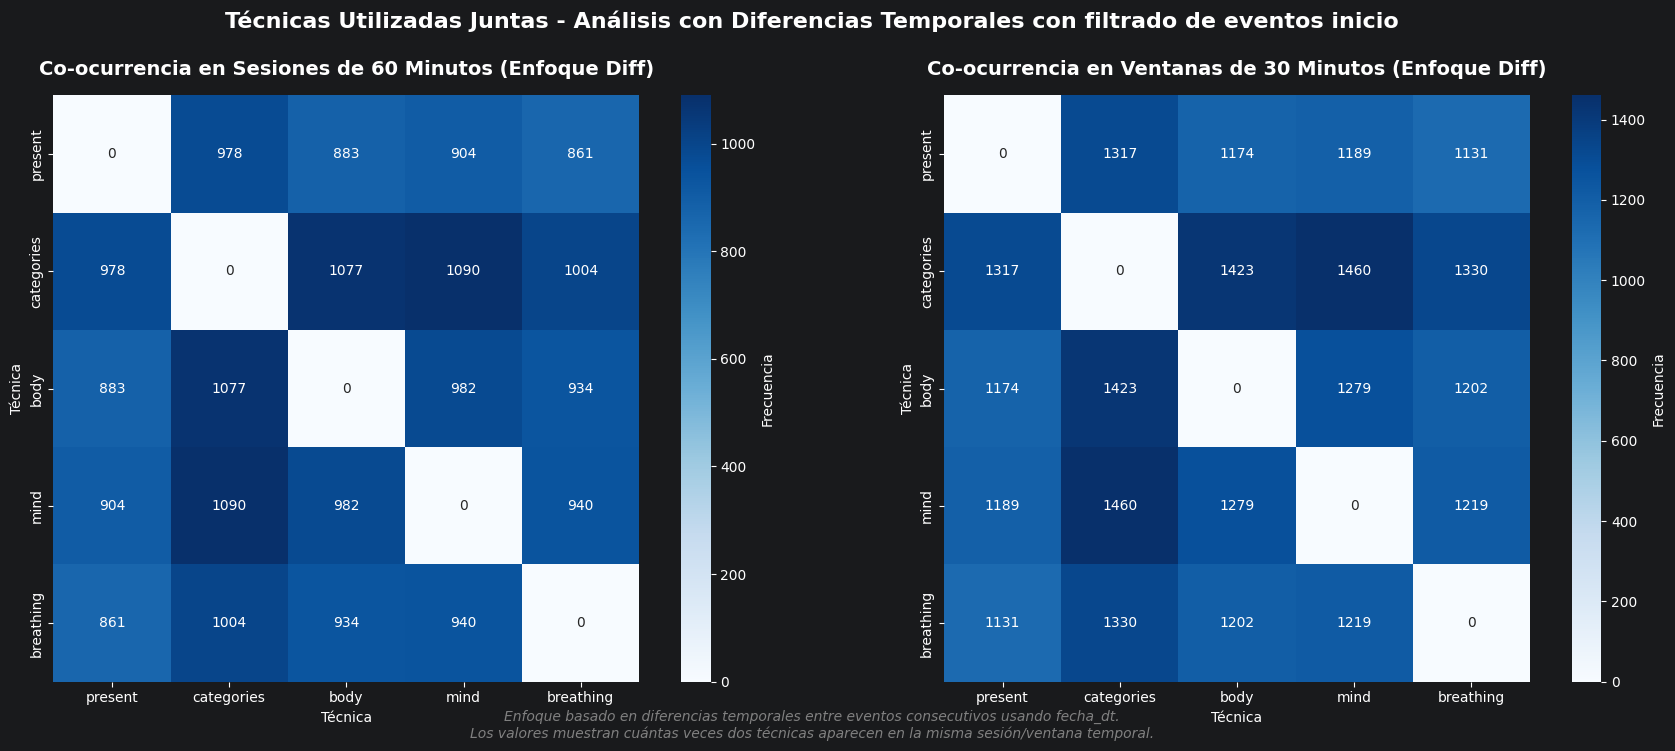


TOP 10 COMBINACIONES EN SESIONES DE 60 MINUTOS (ENFOQUE DIFF)
    Técnica 1   Técnica 2  Frecuencia
5  categories        mind        1090
4  categories        body        1077
6  categories   breathing        1004
7        body        mind         982
0     present  categories         978
9        mind   breathing         940
8        body   breathing         934
2     present        mind         904
1     present        body         883
3     present   breathing         861

TOP 10 COMBINACIONES EN VENTANAS DE 30 MINUTOS (ENFOQUE DIFF)
    Técnica 1   Técnica 2  Frecuencia
5  categories        mind        1460
4  categories        body        1423
6  categories   breathing        1330
0     present  categories        1317
7        body        mind        1279
9        mind   breathing        1219
8        body   breathing        1202
2     present        mind        1189
1     present        body        1174
3     present   breathing        1131


In [83]:
#? 3. Exploracion de analitica de co-ocurenci con filtro de eventos inciados


#? 1.1. Calcular diferencia de tiempo entre eventos consecutivos. La funcion de diff calcula la diferencia numerica o el time delta en horas minutos o segundos
#? de la fila de arriba comparada con la de abajo, haciendo time abajo - time arriba desde la segunda celda para calcular las diferencias temporales entre registros. En nuestro caso
#? la funcion calcula la diferencia entre series de tiempo consecutivas basada en nuestra columna date and time
data_cleaned['time_diff'] = data_cleaned['date_dt'].diff()

#? 1.2 Definimos dos timedeltas, especificamente las diferencias de tiempo en minutos que toleramos para poder comparar los intervalos de tiempo calculados por .diff
#? con los thresholds definidos de 60 y 30 minutos. .diff() retorna timedeltas que representan las diferencias calculadas por lo que al definir estos timedeltas nos permite
#? realizar comparaciones directas
gap_threshold_session = timedelta(minutes=60)  # Sesión: eventos separados por <= 60 minutos
gap_threshold_close = timedelta(minutes=30)    # Momentos cercanos: eventos separados por <= 30 minutos

#? 1.3. Identificar inicio de nuevas sesiones (ventanas de 60 minutos)
#? Si la diferencia de tiempo es mayor a 60 minutos O es el primer evento (NaN), inicia nueva sesión
data_cleaned['new_session_60min'] = (data_cleaned['time_diff'] > gap_threshold_session) | (data_cleaned['time_diff'].isna())

#? 1.4. Asignar ID único a cada sesión mediante suma acumulativa de los marcadores de nueva sesión
#? La funcion cumsum() suma acumulativamente los valores True (1) y False (0), creando un contador que incrementa cada vez que se detecta una nueva sesión
data_cleaned['session_id_60min'] = data_cleaned['new_session_60min'].cumsum()

#? 1.5. Identificar inicio de nuevas ventanas de momentos cercanos (30 minutos)
#? Aplicamos la misma lógica que en 1.3 pero con el threshold de 30 minutos para capturar relaciones temporales más cercanas entre eventos
data_cleaned['new_session_30min'] = (data_cleaned['time_diff'] > gap_threshold_close) | (data_cleaned['time_diff'].isna())

#? 1.6. Asignar ID único a cada ventana de 30 minutos
#? Similar a 1.4, creamos identificadores únicos para cada ventana temporal de 30 minutos mediante suma acumulativa
data_cleaned['session_id_30min'] = data_cleaned['new_session_30min'].cumsum()


#? 1.7. Agrupar técnicas por sesión de 60 minutos
#? Agrupamos todos los eventos que pertenecen a la misma sesión (mismo session_id_60min) y recolectamos todas las técnicas utilizadas en esa sesión en una lista
session_cooccurrence_diff = (
    data_cleaned[data_cleaned['event'] == 'Grounding Started']
        .groupby('session_id_60min')['techniqueID']
        .apply(list)
        .reset_index()
)

#? 1.8. Calcular estadísticas de sesiones de 60 minutos
#? Calculamos el número total de eventos en cada sesión contando la longitud de la lista de técnicas
session_cooccurrence_diff['num_events'] = session_cooccurrence_diff['techniqueID'].apply(len)

#? 1.9. Calcular el número de técnicas únicas por sesión
#? Convertimos la lista de técnicas a un set para eliminar duplicados y luego contamos cuántas técnicas diferentes se usaron en cada sesión
session_cooccurrence_diff['unique_techniques'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))

#? 1.10. Crear lista de técnicas únicas por sesión
#? Guardamos la lista de técnicas únicas (sin duplicados) para cada sesión, lo cual será útil para el análisis de co-ocurrencia posterior
session_cooccurrence_diff['technique_list'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 1.11. Filtrar sesiones con múltiples técnicas
#? Nos enfocamos solo en sesiones donde se usaron 2 o más técnicas diferentes, ya que estas son las que nos interesan para analizar co-ocurrencia
session_cooccurrence_diff_multi = session_cooccurrence_diff[session_cooccurrence_diff['unique_techniques'] > 1].copy()


#? 1.12. Agrupar técnicas por ventana de 30 minutos
#? Aplicamos el mismo proceso de agrupación que en 1.7 pero usando las ventanas de 30 minutos para capturar relaciones temporales más cercanas
close_moment_cooccurrence_diff = (
    data_cleaned[data_cleaned['event'] == 'Grounding Started']
    .groupby('session_id_30min')['techniqueID']
    .apply(list)
    .reset_index()
)

#? 1.13. Calcular estadísticas de ventanas de 30 minutos - Número de eventos
#? Contamos cuántos eventos ocurrieron en cada ventana de 30 minutos
close_moment_cooccurrence_diff['num_events'] = close_moment_cooccurrence_diff['techniqueID'].apply(len)

#? 1.14. Calcular estadísticas de ventanas de 30 minutos - Técnicas únicas
#? Determinamos cuántas técnicas diferentes se utilizaron en cada ventana de 30 minutos
close_moment_cooccurrence_diff['unique_techniques'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))

#? 1.15. Crear lista de técnicas únicas por ventana de 30 minutos
#? Almacenamos las técnicas únicas para cada ventana temporal de 30 minutos
close_moment_cooccurrence_diff['technique_list'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 1.16. Filtrar ventanas de 30 minutos con múltiples técnicas
#? Seleccionamos solo las ventanas donde se usaron 2 o más técnicas diferentes para el análisis de co-ocurrencia
close_moment_cooccurrence_diff_multi = close_moment_cooccurrence_diff[close_moment_cooccurrence_diff['unique_techniques'] > 1].copy()


#? 1.17. Crear matriz de co-ocurrencia para sesiones de 60 minutos
#? Inicializamos una matriz cuadrada con ceros donde las filas y columnas representan todas las técnicas disponibles
techniques = data_cleaned['techniqueID'].unique()
co_occurrence_60min_diff = pd.DataFrame(0, index=techniques, columns=techniques)

#? 1.18. Poblar matriz de co-ocurrencia de 60 minutos
#? Iteramos sobre cada sesión que tiene múltiples técnicas
for tech_list in session_cooccurrence_diff_multi['techniqueID']:
    unique_techs = list(set(tech_list))  # Eliminar duplicados dentro de la misma sesión para evitar contar la misma técnica múltiples veces
    if len(unique_techs) > 1:
        #? Para cada par de técnicas únicas en la sesión, incrementamos el contador en la matriz
        #? Usamos combinations para generar todos los pares posibles sin repetición (A,B) pero no (B,A) como par separado
        for tech1, tech2 in combinations(unique_techs, 2):
            co_occurrence_60min_diff.loc[tech1, tech2] += 1  # Incrementar celda superior
            co_occurrence_60min_diff.loc[tech2, tech1] += 1  # Incrementar celda inferior para mantener simetría

#? 1.19. Crear matriz de co-ocurrencia para ventanas de 30 minutos
#? Inicializamos una segunda matriz para analizar co-ocurrencia en ventanas temporales más cortas
co_occurrence_30min_diff = pd.DataFrame(0, index=techniques, columns=techniques)

#? 1.20. Poblar matriz de co-ocurrencia de 30 minutos
#? Aplicamos la misma lógica que en 1.18 pero para las ventanas de 30 minutos, capturando relaciones temporales más inmediatas
for tech_list in close_moment_cooccurrence_diff_multi['techniqueID']:
    unique_techs = list(set(tech_list))  # Eliminar duplicados
    if len(unique_techs) > 1:
        #? Incrementar contador para cada par de técnicas que co-ocurren en la misma ventana de 30 minutos
        for tech1, tech2 in combinations(unique_techs, 2):
            co_occurrence_30min_diff.loc[tech1, tech2] += 1
            co_occurrence_30min_diff.loc[tech2, tech1] += 1

#? 1.21. Visualización: Heatmaps comparativos de co-ocurrencia con enfoque diff
#? Creamos una figura con dos subplots lado a lado para comparar visualmente los patrones de co-ocurrencia en ambas ventanas temporales
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

#? 1.22. Heatmap para sesiones de 60 minutos
#? Visualizamos la matriz de co-ocurrencia de 60 minutos usando un mapa de calor donde colores más oscuros indican mayor frecuencia de co-ocurrencia
sns.heatmap(
    co_occurrence_60min_diff,
    annot=True,  # Mostrar valores numéricos en cada celda
    fmt='d',     # Formato entero para los valores
    cmap='Blues',  # Paleta de colores azules
    cbar_kws={'label': 'Frecuencia'},  # Etiqueta para la barra de color
    ax=axes[0],
    square=True  # Mantener celdas cuadradas para mejor visualización
)
axes[0].set_title('Co-ocurrencia en Sesiones de 60 Minutos (Enfoque Diff)',
                  fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Técnica', fontsize=10)
axes[0].set_ylabel('Técnica', fontsize=10)

#? 1.23. Heatmap para ventanas de 30 minutos
#? Creamos el segundo heatmap para visualizar co-ocurrencias en ventanas temporales más cortas
sns.heatmap(
    co_occurrence_30min_diff,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar_kws={'label': 'Frecuencia'},
    ax=axes[1],
    square=True
)
axes[1].set_title('Co-ocurrencia en Ventanas de 30 Minutos (Enfoque Diff)',
                  fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Técnica', fontsize=10)
axes[1].set_ylabel('Técnica', fontsize=10)

#? 1.24. Añadir título general y subtítulo explicativo
#? Agregamos contexto sobre la metodología y la interpretación de los resultados
fig.suptitle(
    'Técnicas Utilizadas Juntas - Análisis con Diferencias Temporales con filtrado de eventos inicio',
    fontsize=16, fontweight='bold', y=1.02
)
fig.text(
    0.5, -0.02,
    'Enfoque basado en diferencias temporales entre eventos consecutivos usando fecha_dt.\n'
    'Los valores muestran cuántas veces dos técnicas aparecen en la misma sesión/ventana temporal.',
    ha='center', fontsize=10, fontstyle='italic', color='gray'
)

plt.tight_layout()
plt.show()

#? 1.25. Análisis de las combinaciones más frecuentes (60 minutos)
#? Extraemos y ordenamos los pares de técnicas por frecuencia de co-ocurrencia para identificar las combinaciones más comunes
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES EN SESIONES DE 60 MINUTOS (ENFOQUE DIFF)")
print("=" * 70)
pairs_60min_diff = []

#? 1.26. Iterar sobre la matriz triangular superior para evitar duplicados
#? Solo consideramos i < j para evitar contar el mismo par dos veces (ej: A-B y B-A)
for i, tech1 in enumerate(techniques):
    for j, tech2 in enumerate(techniques):
        if i < j and co_occurrence_60min_diff.loc[tech1, tech2] > 0:
            pairs_60min_diff.append({
                'Técnica 1': tech1,
                'Técnica 2': tech2,
                'Frecuencia': co_occurrence_60min_diff.loc[tech1, tech2]
            })

#? 1.27. Convertir a DataFrame y ordenar por frecuencia descendente
#? Organizamos los pares de técnicas de mayor a menor frecuencia para identificar las combinaciones más relevantes
pairs_60min_diff_df = pd.DataFrame(pairs_60min_diff).sort_values('Frecuencia', ascending=False)
print(pairs_60min_diff_df.head(10))

#? 1.28. Análisis de las combinaciones más frecuentes (30 minutos)
#? Repetimos el análisis para las ventanas de 30 minutos para comparar patrones de co-ocurrencia en diferentes escalas temporales
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES EN VENTANAS DE 30 MINUTOS (ENFOQUE DIFF)")
print("=" * 70)
pairs_30min_diff = []

#? 1.29. Extraer pares de técnicas de la matriz de 30 minutos
#? Aplicamos la misma lógica de extracción que en 1.26 pero para la ventana temporal más corta
for i, tech1 in enumerate(techniques):
    for j, tech2 in enumerate(techniques):
        if i < j and co_occurrence_30min_diff.loc[tech1, tech2] > 0:
            pairs_30min_diff.append({
                'Técnica 1': tech1,
                'Técnica 2': tech2,
                'Frecuencia': co_occurrence_30min_diff.loc[tech1, tech2]
            })

#? 1.30. Ordenar y mostrar las combinaciones más frecuentes de 30 minutos
#? Presentamos las 10 combinaciones más comunes en ventanas de 30 minutos para identificar relaciones temporales inmediatas entre técnicas
pairs_30min_diff_df = pd.DataFrame(pairs_30min_diff).sort_values('Frecuencia', ascending=False)
print(pairs_30min_diff_df.head(10))


DISTRIBUCIÓN DE SESIONES DE 60 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)
1 técnica(s): 548 sesiones (22.62%)
2 técnica(s): 608 sesiones (25.09%)
3 técnica(s): 391 sesiones (16.14%)
4 técnica(s): 222 sesiones (9.16%)
5 técnica(s): 654 sesiones (26.99%)

DISTRIBUCIÓN DE VENTANAS DE 30 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)
1 técnica(s): 826 ventanas (24.27%)
2 técnica(s): 885 ventanas (26.01%)
3 técnica(s): 543 ventanas (15.96%)
4 técnica(s): 320 ventanas (9.40%)
5 técnica(s): 829 ventanas (24.36%)

RESUMEN - SESIONES/VENTANAS CON MÚLTIPLES TÉCNICAS (DIFF)
Sesiones de 60 min con 2+ técnicas: 1875 (77.38%)
Ventanas de 30 min con 2+ técnicas: 2577 (75.73%)


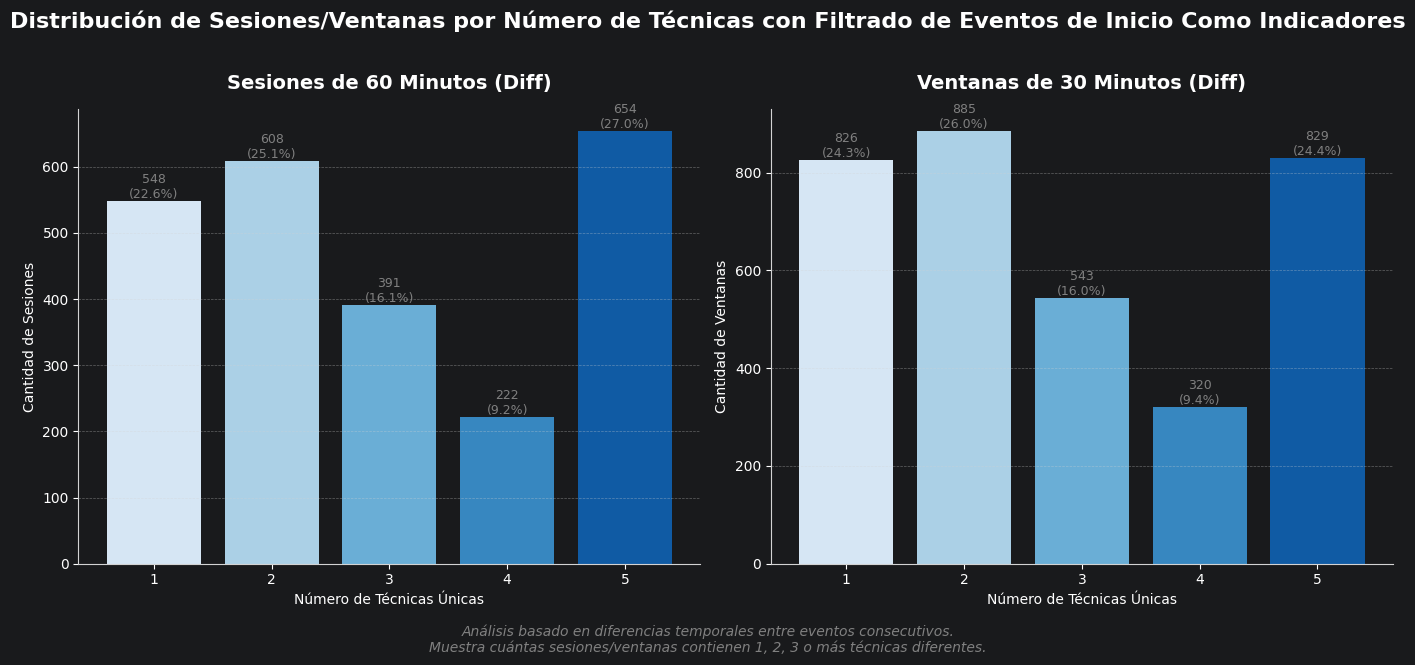


TOP 10 COMBINACIONES ESPECÍFICAS - SESIONES DE 60 MINUTOS (DIFF)
                                       Combinación  Frecuencia
0   body + breathing + categories + mind + present         654
1                                categories + mind         110
20                               body + categories         102
10            body + breathing + categories + mind          76
23                            categories + present          71
4                           breathing + categories          63
16                        body + categories + mind          62
6                                      body + mind          56
7               body + categories + mind + present          55
18                   body + breathing + categories          54

TOP 10 COMBINACIONES ESPECÍFICAS - VENTANAS DE 30 MINUTOS (DIFF)
                                       Combinación  Frecuencia
0   body + breathing + categories + mind + present         829
1                                categories + min

In [112]:
#? 4. Análisis de sesiones por cantidad de técnicas utilizadas (Enfoque Diff) con filtro de grounding start


#? 2.1. Calcular técnicas únicas por sesión de 60 minutos
#? Aplicamos una función lambda que convierte la lista de técnicas a un set (eliminando duplicados) y cuenta cuántas técnicas únicas hay en cada sesión
session_cooccurrence_diff['unique_techniques'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))

#? 2.2. Crear lista de técnicas únicas por sesión de 60 minutos
#? Guardamos las técnicas únicas como lista para facilitar análisis posteriores de combinaciones específicas
session_cooccurrence_diff['technique_list'] = session_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 2.3. Contar sesiones por número de técnicas únicas (60 minutos)
#? Usamos value_counts() para obtener la frecuencia de cada cantidad de técnicas y sort_index() para ordenar de menor a mayor número de técnicas
session_technique_counts_diff = session_cooccurrence_diff['unique_techniques'].value_counts().sort_index()

#? 2.4. Mostrar distribución de sesiones de 60 minutos
#? Imprimimos un resumen que muestra cuántas sesiones tienen 1, 2, 3, etc. técnicas, junto con el porcentaje que representa del total
print("=" * 70)
print("DISTRIBUCIÓN DE SESIONES DE 60 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)")
print("=" * 70)
for num_techs, count in session_technique_counts_diff.items():
    pct = count / len(session_cooccurrence_diff) * 100
    print(f"{num_techs} técnica(s): {count} sesiones ({pct:.2f}%)")

#? 2.5. Calcular técnicas únicas por ventana de 30 minutos
#? Repetimos el proceso de 2.1 pero para las ventanas temporales más cortas de 30 minutos
close_moment_cooccurrence_diff['unique_techniques'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: len(set(x)))

#? 2.6. Crear lista de técnicas únicas por ventana de 30 minutos
#? Almacenamos las técnicas únicas de cada ventana de 30 minutos para análisis detallado de combinaciones
close_moment_cooccurrence_diff['technique_list'] = close_moment_cooccurrence_diff['techniqueID'].apply(lambda x: list(set(x)))

#? 2.7. Contar ventanas por número de técnicas únicas (30 minutos)
#? Generamos la distribución de frecuencias para las ventanas de 30 minutos, similar a 2.3
close_moment_technique_counts_diff = close_moment_cooccurrence_diff['unique_techniques'].value_counts().sort_index()

#? 2.8. Mostrar distribución de ventanas de 30 minutos
#? Presentamos el resumen de cuántas ventanas contienen cada cantidad de técnicas únicas
print("\n" + "=" * 70)
print("DISTRIBUCIÓN DE VENTANAS DE 30 MINUTOS POR NÚMERO DE TÉCNICAS (DIFF)")
print("=" * 70)
for num_techs, count in close_moment_technique_counts_diff.items():
    pct = count / len(close_moment_cooccurrence_diff) * 100
    print(f"{num_techs} técnica(s): {count} ventanas ({pct:.2f}%)")

#? 2.9. Filtrar sesiones/ventanas con 2 o más técnicas
#? Seleccionamos solo las sesiones y ventanas que tienen múltiples técnicas, ya que estas son las relevantes para analizar co-ocurrencia
session_multi_tech_diff = session_cooccurrence_diff[session_cooccurrence_diff['unique_techniques'] >= 2]
close_moment_multi_tech_diff = close_moment_cooccurrence_diff[close_moment_cooccurrence_diff['unique_techniques'] >= 2]

print("\n" + "=" * 70)
print("RESUMEN - SESIONES/VENTANAS CON MÚLTIPLES TÉCNICAS (DIFF)")
print("=" * 70)
print(f"Sesiones de 60 min con 2+ técnicas: {len(session_multi_tech_diff)} ({len(session_multi_tech_diff)/len(session_cooccurrence_diff)*100:.2f}%)")
print(f"Ventanas de 30 min con 2+ técnicas: {len(close_moment_multi_tech_diff)} ({len(close_moment_multi_tech_diff)/len(close_moment_cooccurrence_diff)*100:.2f}%)")

#? 2.11. Visualización: Gráfico de barras comparativo (Enfoque Diff)
#? Creamos una figura con dos subplots para comparar visualmente las distribuciones de ambas ventanas temporales
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#? 2.12. Generar paleta de colores para gráfico de 60 minutos
#? Usamos la función generate_blue_palette para crear una gradiente de azules según el número de categorías
colors_60min = generate_blue_palette(len(session_technique_counts_diff))

#? 2.13. Crear gráfico de barras para sesiones de 60 minutos
#? Visualizamos la distribución de sesiones por número de técnicas usando barras verticales
axes[0].bar(session_technique_counts_diff.index, session_technique_counts_diff.values, color=colors_60min)
axes[0].set_title('Sesiones de 60 Minutos (Diff)', fontsize=14, fontweight='bold', pad=15)
axes[0].set_xlabel('Número de Técnicas Únicas', fontsize=10)
axes[0].set_ylabel('Cantidad de Sesiones', fontsize=10)

#? 2.14. Configurar estilo del gráfico de 60 minutos
#? Añadimos grid horizontal y configuramos los spines (bordes) para un estilo minimalista
axes[0].grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].spines['left'].set_color('lightgray')
axes[0].spines['bottom'].set_color('lightgray')

#? 2.15. Añadir etiquetas con conteo y porcentaje (60 minutos)
#? Colocamos texto sobre cada barra mostrando el conteo absoluto y el porcentaje del total
for i, (num, count) in enumerate(session_technique_counts_diff.items()):
    axes[0].text(num, count, f'{count}\n({count/len(session_cooccurrence_diff)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, color='gray')

#? 2.16. Generar paleta de colores para gráfico de 30 minutos
#? Creamos una nueva paleta de colores para el segundo gráfico
colors_30min = generate_blue_palette(len(close_moment_technique_counts_diff))

#? 2.17. Crear gráfico de barras para ventanas de 30 minutos
#? Visualizamos la distribución de ventanas de 30 minutos por número de técnicas
axes[1].bar(close_moment_technique_counts_diff.index, close_moment_technique_counts_diff.values, color=colors_30min)
axes[1].set_title('Ventanas de 30 Minutos (Diff)', fontsize=14, fontweight='bold', pad=15)
axes[1].set_xlabel('Número de Técnicas Únicas', fontsize=10)
axes[1].set_ylabel('Cantidad de Ventanas', fontsize=10)

#? 2.18. Configurar estilo del gráfico de 30 minutos
#? Aplicamos el mismo estilo minimalista que en el gráfico de 60 minutos para mantener consistencia visual
axes[1].grid(True, axis='y', color='lightgray', linestyle='--', alpha=0.4)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].spines['left'].set_color('lightgray')
axes[1].spines['bottom'].set_color('lightgray')

#? 2.19. Añadir etiquetas con conteo y porcentaje (30 minutos)
#? Mostramos los valores numéricos y porcentajes sobre cada barra del segundo gráfico
for i, (num, count) in enumerate(close_moment_technique_counts_diff.items()):
    axes[1].text(num, count, f'{count}\n({count/len(close_moment_cooccurrence_diff)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, color='gray')

#? 2.20. Añadir título general del gráfico completo
#? Colocamos un título superior que describe ambos subplots
fig.suptitle(
    'Distribución de Sesiones/Ventanas por Número de Técnicas con Filtrado de Eventos de Inicio Como Indicadores',
    fontsize=16, fontweight='bold', y=1.02
)

#? 2.21. Añadir subtítulo explicativo
#? Incluimos una descripción metodológica y de interpretación en la parte inferior
fig.text(
    0.5, -0.05,
    'Análisis basado en diferencias temporales entre eventos consecutivos.\n'
    'Muestra cuántas sesiones/ventanas contienen 1, 2, 3 o más técnicas diferentes.',
    ha='center', fontsize=10, fontstyle='italic', color='gray'
)

plt.tight_layout()
plt.show()

#? 2.23. Iterar sobre sesiones con múltiples técnicas (60 minutos)
#? Procesamos cada sesión que tiene 2 o más técnicas para contar las combinaciones específicas
#? 7. Análisis detallado: Combinaciones específicas más frecuentes (60 minutos)
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES ESPECÍFICAS - SESIONES DE 60 MINUTOS (DIFF)")
print("=" * 70)
combination_counts_60min = {}

for tech_list in session_multi_tech_diff['technique_list']:
    if len(tech_list) >= 2:
        #? 2.24. Crear tupla ordenada para evitar duplicados (A,B) vs (B,A)
        #? Ordenamos alfabéticamente las técnicas para que (A,B) y (B,A) se cuenten como la misma combinación
        combo = tuple(sorted(tech_list))
        combination_counts_60min[combo] = combination_counts_60min.get(combo, 0) + 1

#? 2.25. Convertir a DataFrame y ordenar por frecuencia descendente (60 minutos)
#? Transformamos el diccionario de combinaciones en un DataFrame para facilitar la visualización y ordenamos de mayor a menor frecuencia
combo_60min_df = pd.DataFrame([
    {'Combinación': ' + '.join(combo), 'Frecuencia': count}
    for combo, count in combination_counts_60min.items()
]).sort_values('Frecuencia', ascending=False)

#? 2.26. Mostrar las 10 combinaciones más frecuentes (60 minutos)
print(combo_60min_df.head(10))

#? 8. Análisis detallado: Combinaciones específicas más frecuentes (30 minutos)
print("\n" + "=" * 70)
print("TOP 10 COMBINACIONES ESPECÍFICAS - VENTANAS DE 30 MINUTOS (DIFF)")
print("=" * 70)
combination_counts_30min = {}

#? 2.28. Iterar sobre ventanas con múltiples técnicas (30 minutos)
#? Procesamos cada ventana de 30 minutos que contiene 2 o más técnicas diferentes
for tech_list in close_moment_multi_tech_diff['technique_list']:
    if len(tech_list) >= 2:
        #? 2.29. Crear tupla ordenada para normalizar combinaciones
        #? Aplicamos la misma normalización que en 2.24 para evitar contar duplicados
        combo = tuple(sorted(tech_list))
        combination_counts_30min[combo] = combination_counts_30min.get(combo, 0) + 1

#? 2.30. Convertir a DataFrame y ordenar por frecuencia descendente (30 minutos)
#? Creamos un DataFrame ordenado con las combinaciones más frecuentes en ventanas de 30 minutos
combo_30min_df = pd.DataFrame([
    {'Combinación': ' + '.join(combo), 'Frecuencia': count}
    for combo, count in combination_counts_30min.items()
]).sort_values('Frecuencia', ascending=False)

#? 2.31. Mostrar las 10 combinaciones más frecuentes (30 minutos)
print(combo_30min_df.head(10))

#? 2.32. Estadísticas adicionales: Distribución de tamaño de combinaciones
#? Analizamos cuántas combinaciones existen de cada tamaño (pares, tríos, cuartetos, etc.)
print("\n" + "=" * 70)
print("ESTADÍSTICAS DE TAMAÑO DE COMBINACIONES")
print("=" * 70)

#? 2.33. Calcular distribución de tamaños para sesiones de 60 minutos
#? Extraemos la longitud de cada combinación (número de técnicas que la componen)
combo_sizes_60min = [len(combo) for combo in combination_counts_60min.keys()]

#? 2.34. Mostrar estadísticas de tamaño para sesiones de 60 minutos
#? Contamos cuántas combinaciones hay de cada tamaño (2, 3, 4+ técnicas)
if combo_sizes_60min:
    print(f"Sesiones de 60 min:")
    print(f"  - Combinaciones de 2 técnicas: {combo_sizes_60min.count(2)}")
    print(f"  - Combinaciones de 3 técnicas: {combo_sizes_60min.count(3)}")
    print(f"  - Combinaciones de 4+ técnicas: {sum(1 for x in combo_sizes_60min if x >= 4)}")

#? 2.35. Calcular distribución de tamaños para ventanas de 30 minutos
#? Repetimos el análisis de tamaños para las ventanas temporales más cortas
combo_sizes_30min = [len(combo) for combo in combination_counts_30min.keys()]

#? 2.36. Mostrar estadísticas de tamaño para ventanas de 30 minutos
#? Presentamos la distribución de tamaños de combinaciones en ventanas de 30 minutos
if combo_sizes_30min:
    print(f"\nVentanas de 30 min:")
    print(f"  - Combinaciones de 2 técnicas: {combo_sizes_30min.count(2)}")
    print(f"  - Combinaciones de 3 técnicas: {combo_sizes_30min.count(3)}")
    print(f"  - Combinaciones de 4+ técnicas: {sum(1 for x in combo_sizes_30min if x >= 4)}")


## Sección V: Conclusiones finales

El análisis integral de las técnicas de anclaje revela una serie de patrones interconectados que permiten comprender tanto las preferencias individuales de los usuarios como los comportamientos colectivos a lo largo del tiempo. En vista de los hallazgos obtenidos, se identifica que la frecuencia de uso, las tasas de finalización y los patrones de co-ocurrencia temporal están estrechamente relacionados, formando un ecosistema de comportamiento que responde a factores tanto intrínsecos de cada técnica como extrínsecos relacionados con los momentos del día, los días de la semana y los meses del año. Con esto en mente, la integración de estas tres dimensiones de análisis permite construir una narrativa coherente sobre cómo los usuarios interactúan con las técnicas de grounding y qué factores influyen en su éxito o abandono.

En este contexto, el análisis temporal emerge como el elemento diferenciador más significativo de este estudio. La distribución horaria revela que los usuarios concentran sus sesiones en horarios nocturnos, específicamente entre las 18:00 y la medianoche, lo que sugiere que las técnicas de anclaje son utilizadas principalmente como herramientas de cierre de jornada o preparación para el descanso. No obstante, esta concentración nocturna coincide paradójicamente con las tasas más bajas de finalización, evidenciando que la fatiga acumulada, las distracciones del final del día o la falta de recordatorios sistemáticos impiden que muchas sesiones iniciadas lleguen a completarse. En vista de este patrón, se observa que técnicas como <code>categories</code> sufren especialmente en estos horarios, mientras que <code>present</code> mantiene un comportamiento anómalo con tasas de finalización extraordinariamente altas que sugieren posibles errores sistemáticos de registro en la aplicación.

El análisis semanal complementa esta visión temporal al mostrar que los días laborales, particularmente de martes a viernes y hasta el sabado, concentran la menor actividad de inicio de sesiones, con un decrecimiento paulatino hasta el sabado, mientras que los fines de semana, y el lunes, presentan un incremento notable. Este comportamiento refuerza la hipótesis de que los usuarios recurren a las técnicas de grounding como respuesta al estrés acumulado durante la semana laboral, buscando herramientas de regulación emocional en momentos de menor carga pero con el objetivo de afrontar nuevas semanas laborales. En este sentido, la distribución mensual revela una estabilidad relativa en el uso de las técnicas a lo largo de los primeros meses del año, sin picos estacionales marcados, lo que indica que la demanda de estas herramientas se mantiene constante independientemente de factores externos como cambios climáticos o períodos vacacionales.

La integración del análisis de co-ocurrencia temporal con los patrones de frecuencia y finalización permite identificar relaciones complementarias entre técnicas. En vista de los resultados, se observa que <code>categories</code> actúa como punto de entrada principal cuando se filtran únicamente los eventos de inicio, co-ocurriendo frecuentemente con <code>body</code>, <code>mind</code> y <code>breathing</code> en ventanas de 30 y 60 minutos. Este patrón sugiere que los usuarios que inician sesiones con <code>categories</code> tienden a explorar otras técnicas en momentos cercanos, posiblemente buscando alternativas cuando la primera no satisface sus necesidades. Por otro lado, la técnica <code>present</code>, cuando se incluyen eventos de finalización, domina las matrices de co-ocurrencia de manera desproporcionada, lo que refuerza la sospecha de errores sistemáticos de registro que inflan artificialmente su presencia en los datos. Esta distinción metodológica entre analizar eventos de inicio versus eventos de finalización resulta crucial para obtener conclusiones válidas sobre el comportamiento real de los usuarios.

En conjunto, los hallazgos revelan que las preferencias de los usuarios están determinadas por una combinación de factores temporales, funcionales y contextuales. Los usuarios prefieren iniciar sesiones en horarios nocturnos y fines de semana, buscan técnicas que ofrezcan una experiencia de finalización satisfactoria como <code>breathing</code> y <code>body</code>, y tienden a explorar múltiples técnicas en momentos cercanos cuando la primera opción no cumple sus expectativas. Con esto en mente, se identifican oportunidades claras para mejorar la experiencia de usuario mediante intervenciones específicas:

- Implementar recordatorios de finalización en horarios nocturnos,
- Optimizar la experiencia de <code>categories</code> para reducir su alta tasa de abandono,
- Corregir los posibles errores de registro en <code>present</code>, y
- Diseñar sistemas de recomendación que aprovechen los patrones de co-ocurrencia temporal para sugerir técnicas complementarias en momentos estratégicos.

El valor añadido del análisis temporal por hora del día, día de la semana y mes permite contextualizar estos comportamientos dentro de los ritmos naturales de vida de los usuarios, ofreciendo una base sólida para decisiones de diseño y estrategia que respondan a necesidades reales en momentos específicos.
